In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [13]:
df = pd.read_csv('Tourism Quantity Data.csv')
df['Continente'] = df['Continente'].fillna('NA') # estavam vazios por algum motivo

### 1 Visão geral dos dados

In [18]:
cols_selecionadas = ['Arrivals', 'Receipts', 'Expenditures', 'Population']

eda_estatistica = df[cols_selecionadas].agg([
    'mean', 
    'median', 
    'std',
    'var',
    lambda x: x.quantile(0.75) - x.quantile(0.25)
]).transpose()

eda_estatistica.columns = [
    'Média', 
    'Mediana', 
    'Desvio Padrão', 
    'Variância', 
    'IQR (Intervalo Interquartil)'
]

print("--- Estatística Descritiva de algumas Variáveis ---")
display(eda_estatistica)

--- Estatística Descritiva de algumas Variáveis ---


,Média,Mediana,Desvio Padrão,Variância,IQR (Intervalo Interquartil)
Arrivals,1.050880e+07,1.877000e+06,2.653321e+07,7.040110e+14,6.292500e+06
Receipts,6.294386e+09,1.154000e+09,1.757620e+10,3.089228e+20,5.427000e+09
Expenditures,5.537331e+09,6.700000e+08,1.509840e+10,2.279618e+20,3.964750e+09
Population,3.971118e+07,8.484550e+06,1.461596e+08,2.136261e+16,2.568192e+07


Veremos a distribuição das receitas, expenditures e chegadas nos histogramas abaixo

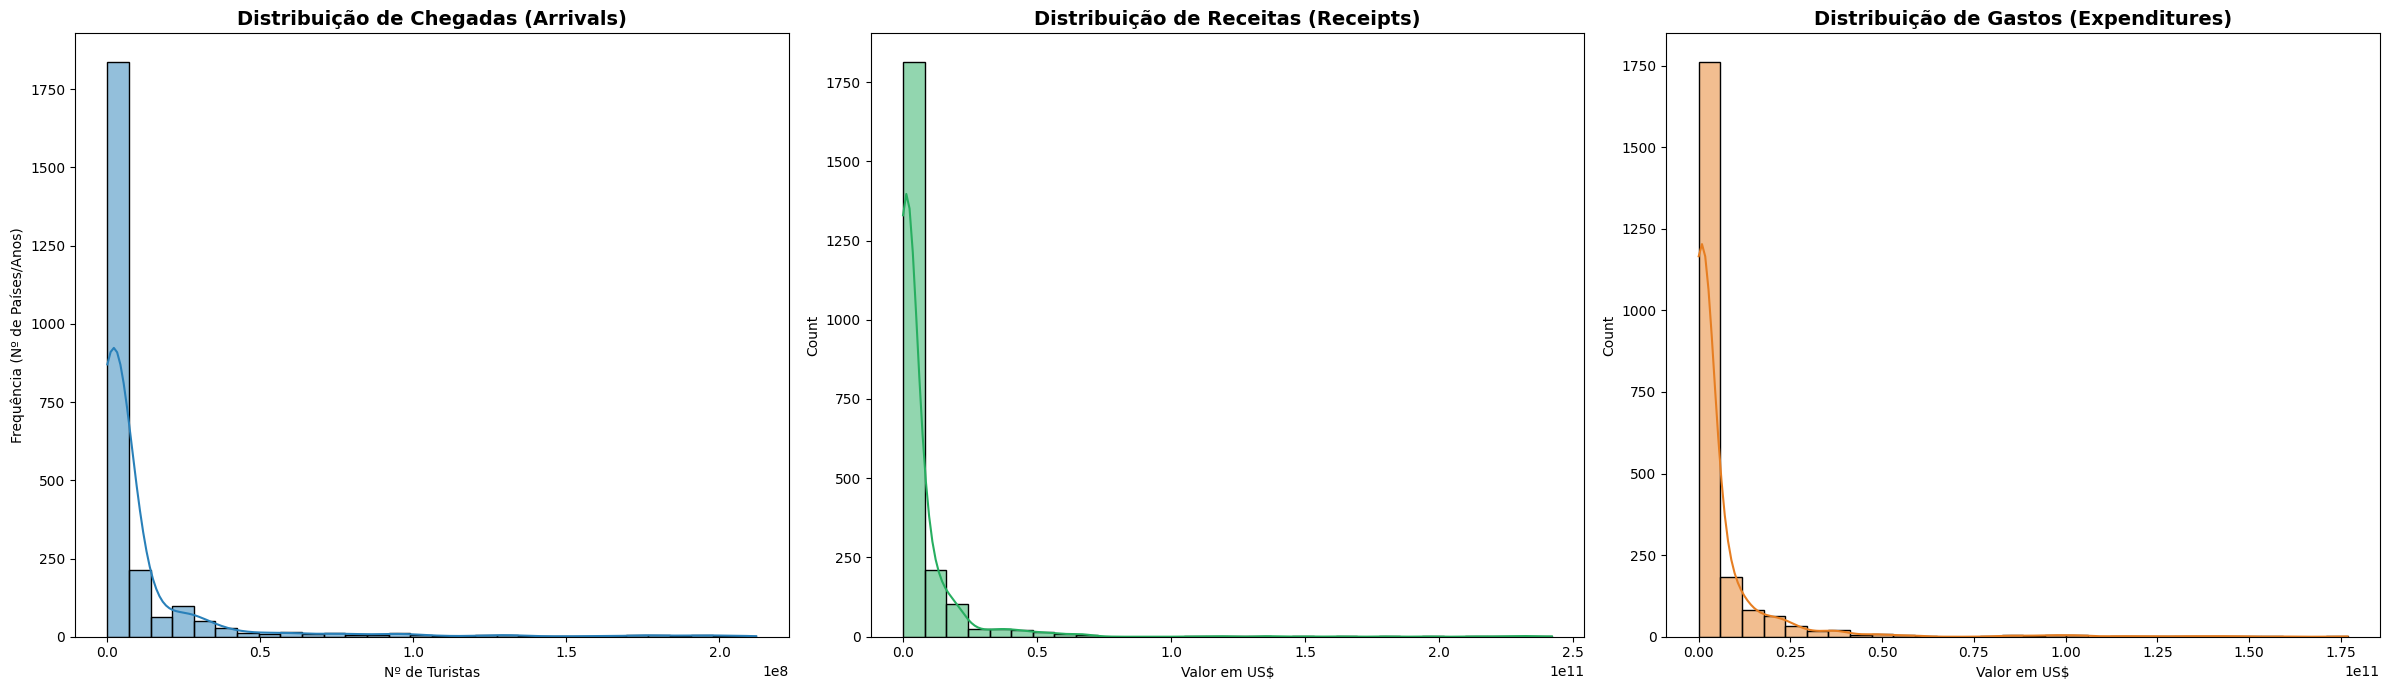

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Gráfico Arrivals
sns.histplot(df['Arrivals'], kde=True, color='#2980b9', ax=axes[0], bins=30)
axes[0].set_title('Distribuição de Chegadas (Arrivals)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Nº de Turistas')
axes[0].set_ylabel('Frequência (Nº de Países/Anos)')

# Gráfico Receipts
sns.histplot(df['Receipts'], kde=True, color='#27ae60', ax=axes[1], bins=30)
axes[1].set_title('Distribuição de Receitas (Receipts)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Valor em US$')

# Gráfico expenditures
sns.histplot(df['Expenditures'], kde=True, color='#e67e22', ax=axes[2], bins=30)
axes[2].set_title('Distribuição de Gastos (Expenditures)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Valor em US$')

plt.tight_layout()
plt.show()

### 2 Evolução global do turismo

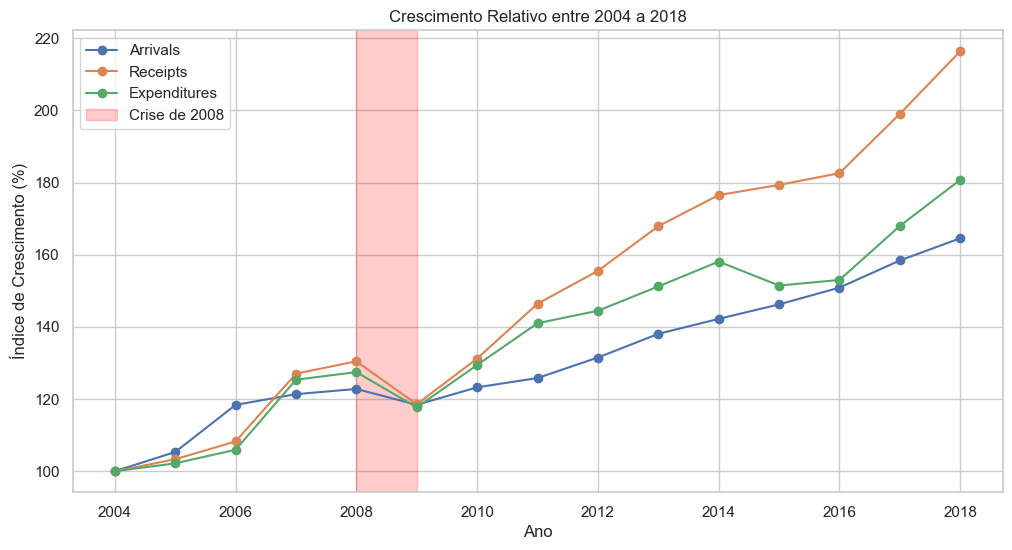


Variação Percentual entre os anos de 2008 e 2009 (%):
Arrivals       -3.575413
Receipts       -9.120784
Expenditures   -7.646947
Name: 2009, dtype: float64


In [95]:
evolucao_global = df.groupby('Ano')[['Arrivals', 'Receipts', 'Expenditures']].sum()

# Normalizando os dados para deixa-los na mesma proporção
evolucao_indexada = (evolucao_global / evolucao_global.iloc[0]) * 100

plt.figure(figsize=(12, 6))
for coluna in evolucao_indexada.columns:
    plt.plot(evolucao_indexada.index, evolucao_indexada[coluna], marker='o', label=coluna)

#Crise de 2008
plt.axvspan(2008, 2009, color='red', alpha=0.2, label='Crise de 2008')

plt.title('Crescimento Relativo entre 2004 a 2018')
plt.ylabel('Índice de Crescimento (%)')
plt.xlabel('Ano')
plt.legend()
plt.grid(True)
plt.show()

# filtrando os anos da crise
df_crise = df[df['Ano'].isin([2008, 2009])]
comparativo = df_crise.groupby('Ano')[['Arrivals', 'Receipts', 'Expenditures']].sum()
variacao_percentual = (comparativo.pct_change() * 100).iloc[-1]

print("\nVariação Percentual entre os anos de 2008 e 2009 (%):")
print(variacao_percentual)

A análise da evolução global entre 2004 e 2018 revela um setor de turismo que está em expansão desde então. Embora a crise financeira de 2008 tenha interrompido a tendência de alta, gerando um declínio entre 2008 e 2009, especialmente nos gastos e receitas e tendo uma recuperação rápida logo após. O crescimento acumulado ao fim do período valida o turismo como um dos principais motores da economia mundial, que foi capaz de se superar rapidamente da crise de 2008.

### 3 Participação no turismo por continente

**Antes de tudo vamos visualizar como estão distribuidos os IncomeGroups pelos continentes**

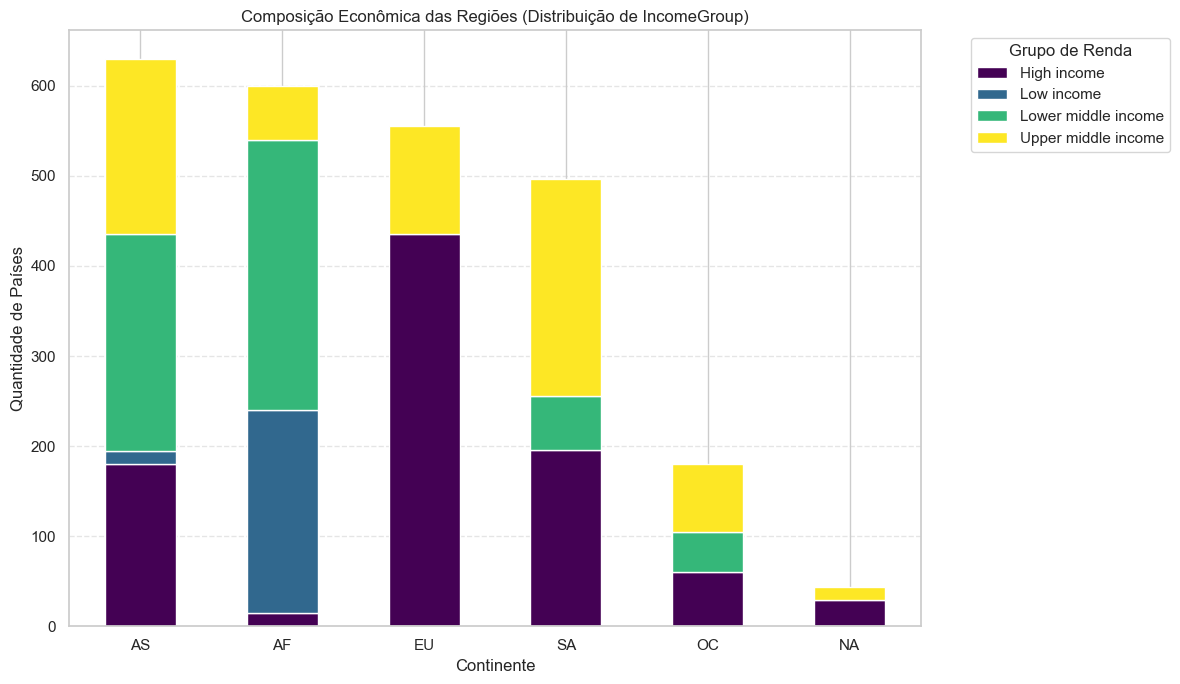

In [119]:
# conta quantos paises existem em cada continente por faixa de renda
df_composicao = df.groupby(['Continente', 'IncomeGroup']).size().unstack(fill_value=0)

# 2. Ordenar os continentes pelo total de países para melhor visualização
df_composicao['Total'] = df_composicao.sum(axis=1)
df_composicao = df_composicao.sort_values('Total', ascending=False).drop(columns='Total')

# Gráfico de Barras Empilhadas (Composição de Riqueza)
df_composicao.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')

plt.title('Composição Econômica das Regiões (Distribuição de IncomeGroup)')
plt.ylabel('Quantidade de Países')
plt.xlabel('Continente')
plt.legend(title='Grupo de Renda', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Agora vejamos o ranking dos continentes acerca do turismo**

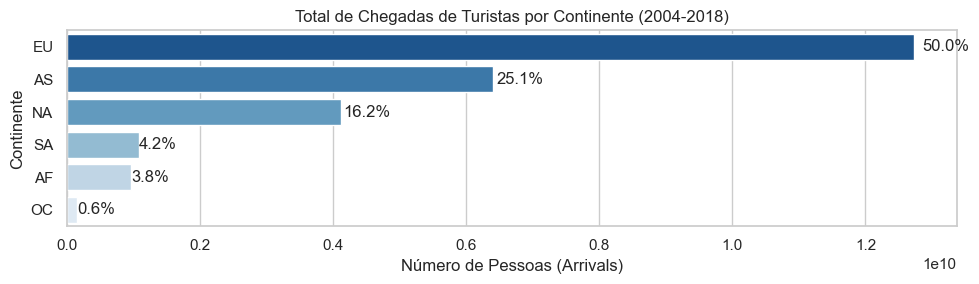

In [ ]:
#estilo visual
#sns.set_theme(style="whitegrid")

# somando os totais por continente de 2004 a 2018
df_continentes = (
    df.groupby('Continente')[['Arrivals']]
    .sum()
    .sort_values(by='Arrivals', ascending=False)
    .reset_index()
)

# porcentagem do total de chegadas de cada continente
total = df_continentes['Arrivals'].sum()
df_continentes['percentual'] = (df_continentes['Arrivals'] / total) * 100

# criando o gráfico
fig, axes = plt.subplots(1, 1, figsize=(10, 3))

ax = sns.barplot(
    data=df_continentes,
    x='Arrivals',
    y='Continente',
    palette='Blues_r'
)

axes.set_title('Total de Chegadas de Turistas por Continente (2004-2018)')
axes.set_xlabel('Número de Pessoas (Arrivals)')

#adicionando porcentagem nas barras
for i, row in df_continentes.iterrows():
    ax.text(
        row['Arrivals'] * 1.01,
        i,
        f"{row['percentual']:.1f}%",
        va='center'
    )

plt.tight_layout()
plt.show()

Os gráficos de barras revelam uma forte concentração do turismo global no continente europeu com 50% de todas as chegas de turistas. Enquando isso, Ásia e América do Norte vem atrás, mesmo juntas não somam a quantidade da Europa. Enquando regiões como a África, América do Sul e Oceania apresentam participações pequenas. Essa diferença evidencia que o mercado de turismo internacional ainda é fortemente centrado em destinos tradicionais do hemisfério norte.

**Abaixo veremos o gráfico de receitas totais de acordo com o continente no período de 2004 a 2018**

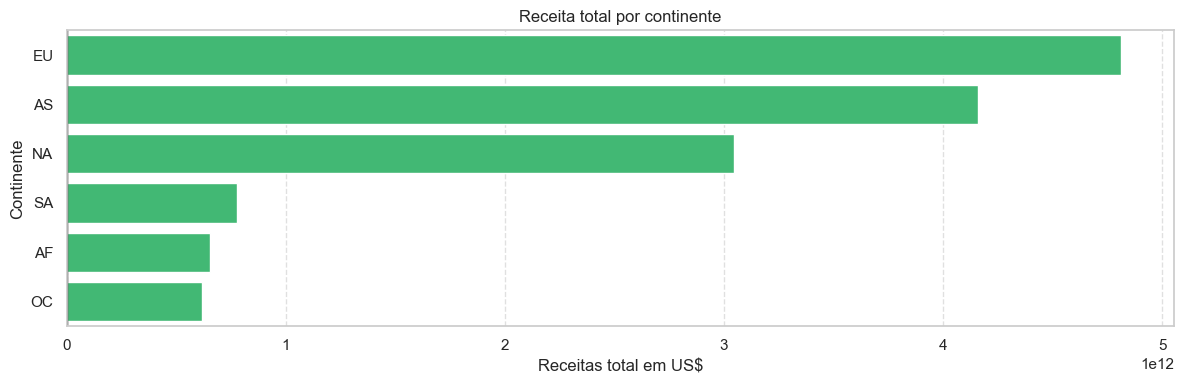

In [172]:
# agrupando por continente e somando as receitas totais
df_regiao = df.groupby('Continente')[['Receipts']].sum().reset_index()

df_regiao = df_regiao.sort_values(by='Receipts', ascending=False)

plt.figure(figsize=(12, 4))
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in df_regiao['Receipts']]

sns.barplot(data=df_regiao, x='Receipts', y='Continente', palette=colors, hue='Continente', legend=False)

plt.axvline(0, color='black', linestyle='-', linewidth=1)
plt.title('Receita total por continente')
plt.xlabel('Receitas total em US$')
plt.ylabel('Continente')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Dá pra ver uma relação: continentes com mais países ricos tendem a gerar mais receita com turismo no total. É o caso da Europa, Ásia e América do Norte, que concentram economias mais fortes e, por isso, provavelmente conseguem atrair mais turistas e gerar mais dinheiro com isso.

### 4 Comparitivo de Receita e Chegada dos top 10 países nos intervalos de 2004-2009 e 2013-2018

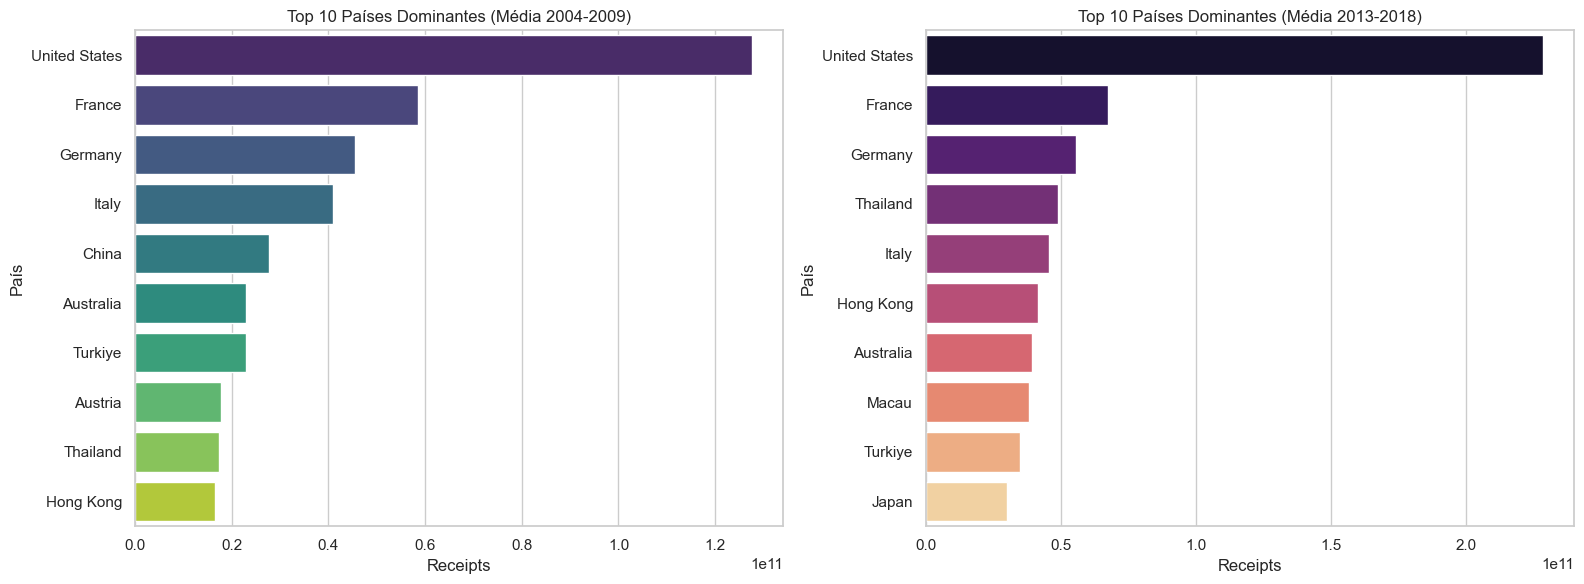

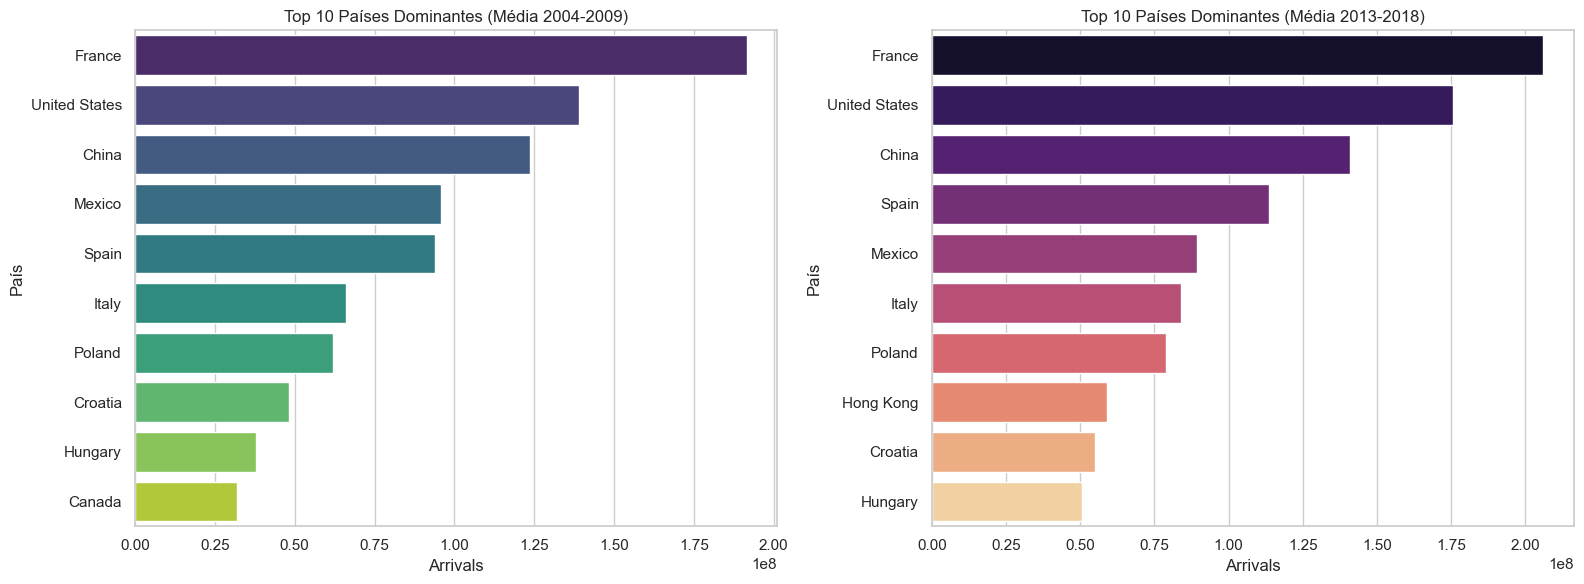

In [193]:
#PRIMEIRO GRAFICO SOBRE RECEITAS
# Agrupamos por País e pegamos os 10 maiores com base na média do período, pegamos um período pois em alguns países está faltando dados
df_intervalo_1 = df[df['Ano'].between(2004, 2009)].groupby('País')['Receipts'].mean().nlargest(10).reset_index()
df_intervalo_2 = df[df['Ano'].between(2013, 2018)].groupby('País')['Receipts'].mean().nlargest(10).reset_index()

# Criar a comparação visual
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=df_intervalo_1, x='Receipts', y='País', palette='viridis', ax=ax1, legend=False)
ax1.set_title('Top 10 Países Dominantes (Média 2004-2009)')

sns.barplot(data=df_intervalo_2, x='Receipts', y='País', palette='magma', ax=ax2, legend=False)
ax2.set_title('Top 10 Países Dominantes (Média 2013-2018)')

plt.tight_layout()
plt.show()

#SEGUNDO GRAFICO SOBRE CHEGADAS
df_intervalo_1 = df[df['Ano'].between(2004, 2009)].groupby('País')['Arrivals'].mean().nlargest(10).reset_index()
df_intervalo_2 = df[df['Ano'].between(2013, 2018)].groupby('País')['Arrivals'].mean().nlargest(10).reset_index()

# Criar a comparação visual
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=df_intervalo_1, x='Arrivals', y='País', palette='viridis', ax=ax1, legend=False)
ax1.set_title('Top 10 Países Dominantes (Média 2004-2009)')

sns.barplot(data=df_intervalo_2, x='Arrivals', y='País', palette='magma', ax=ax2, legend=False)
ax2.set_title('Top 10 Países Dominantes (Média 2013-2018)')

plt.tight_layout()
plt.show()

Podemos notar que muitos paises se mantiveram no topo dos países com mais receitas e chegadas, enquanto outros sairem ou entraram do top 10.

*obs: provavelmente a china ficou fora em receipts do segundo gráfico pois não possui dados nos anos próximos de 2018*

### 5 Turismo vs Receita, existe correlação?

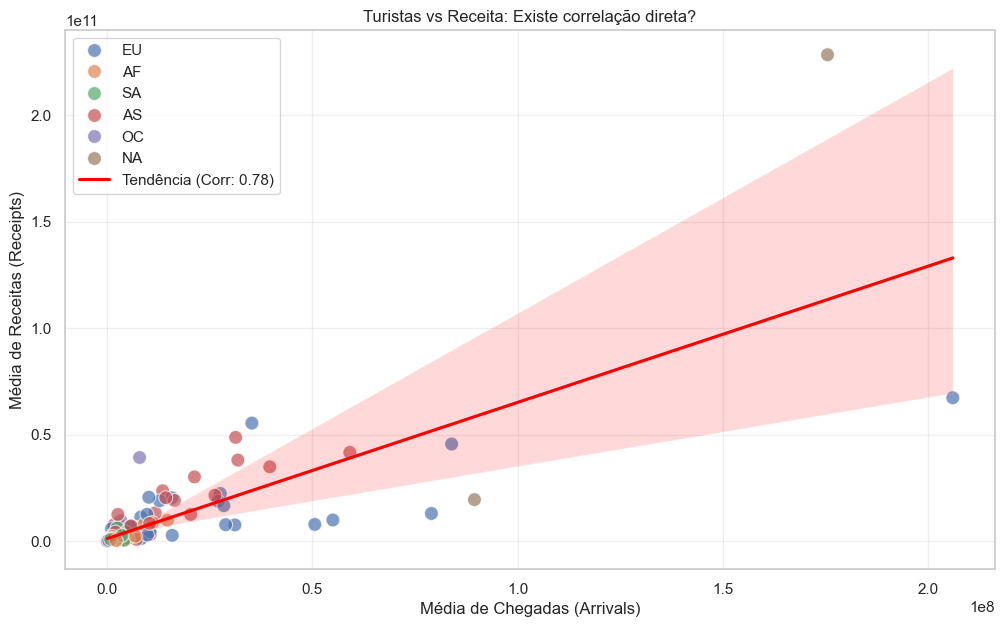

In [365]:
# vamos pegar a media dos dados de um período para evitar oscilações de um unico ano
df_relacao = df[df['Ano'] >= 2013].groupby(['País', 'Continente']).agg({
    'Arrivals': 'mean',
    'Receipts': 'mean'
}).reset_index()


# Calculando correlação
correlacao = df_relacao['Arrivals'].corr(df_relacao['Receipts'])

# plotando sccater
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_relacao, x='Arrivals', y='Receipts', hue='Continente', s=100, alpha=0.7)
sns.regplot(data=df_relacao, x='Arrivals', y='Receipts', scatter=False, color='red', label=f'Tendência (Corr: {correlacao:.2f})')

plt.title('Turistas vs Receita: Existe correlação direta?')
#plt.xlim(0, 20_000_000)   # limite do eixo X
#plt.ylim(0, 20_000_000_000)  # limite do eixo Y
plt.xlabel('Média de Chegadas (Arrivals)')
plt.ylabel('Média de Receitas (Receipts)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

O gráfico mostra que existe uma relação entre quantidade de turistas e dinheiro gerado: quanto mais visitantes, maior tende a ser a receita. Mas, alguns lugares conseguem ganhar muito dinheiro mesmo sem receber tanta gente. Esses são destinos mais “eficientes”, que aproveitam melhor cada turista o contrário também acontece.

### 6. Receita vs Gastos

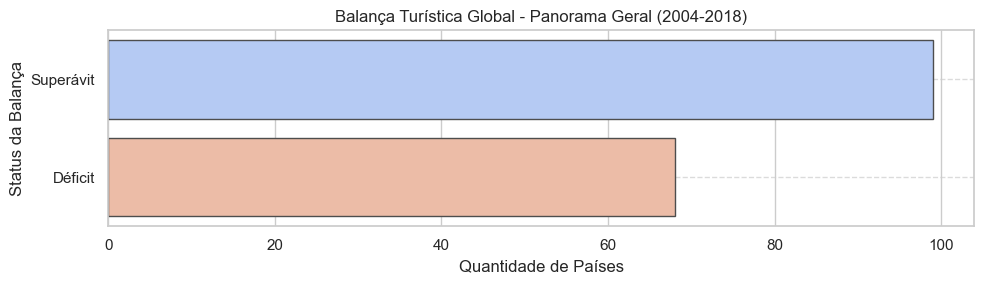

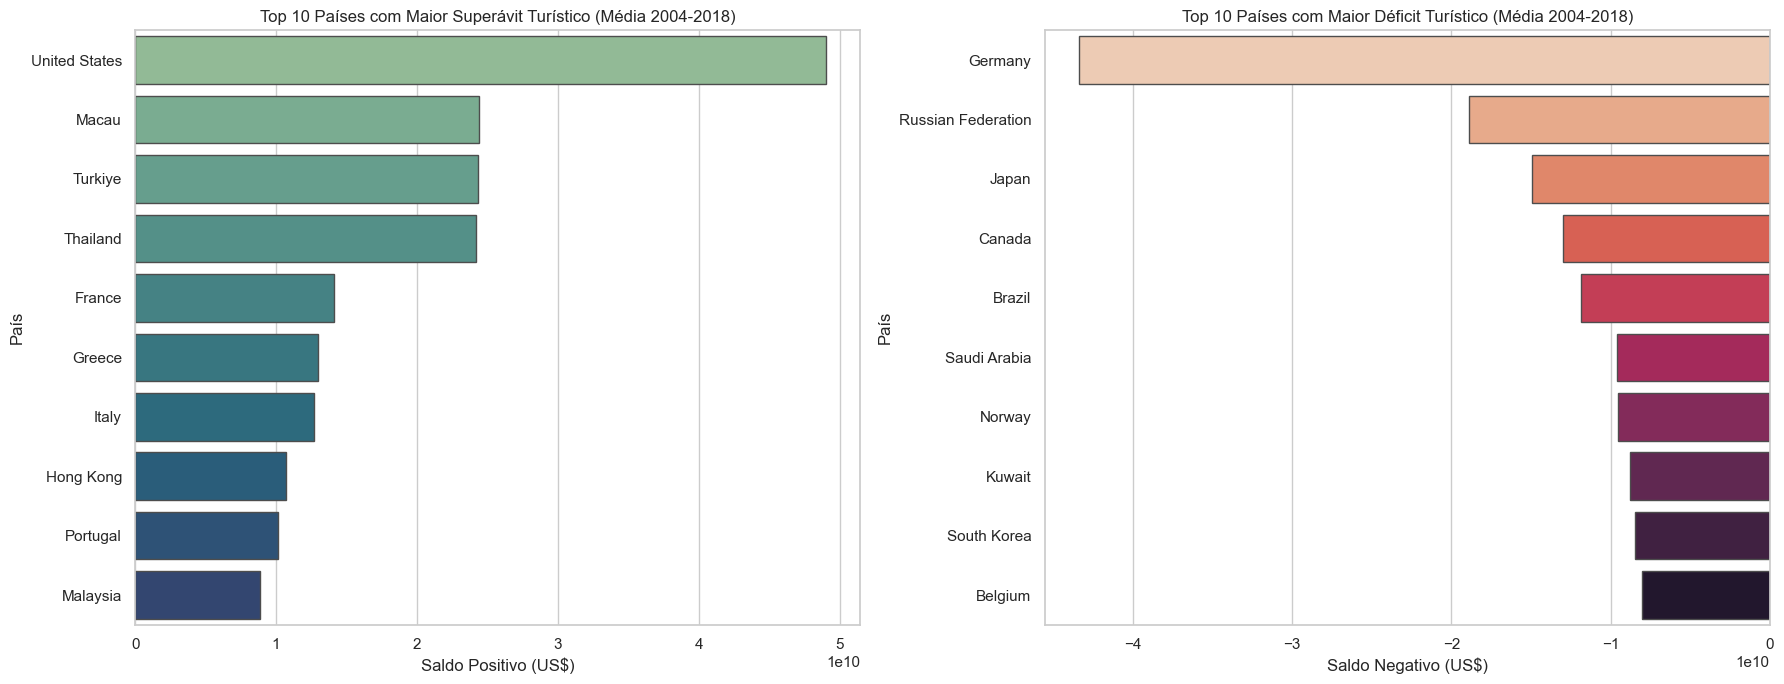

In [491]:
df_balanca = df.groupby('País')[['Receipts', 'Expenditures']].mean().reset_index()

# Superavit: Receita > Gasto | Deficit: Gasto > Receita
df_balanca['Saldo'] = df_balanca['Receipts'] - df_balanca['Expenditures']
df_balanca['Status'] = df_balanca['Saldo'].apply(lambda x: 'Superávit' if x > 0 else 'Déficit')

contagem = df_balanca['Status'].value_counts().reset_index()
contagem.columns = ['Status', 'Total']

# GRAFICO GLOBAL DA BALANCA TURISTAL
plt.figure(figsize=(10, 3))
sns.barplot(data=contagem, edgecolor='0.3', linewidth=1, y='Status', x='Total', hue='Status', palette='coolwarm', legend=False)

plt.title('Balança Turística Global - Panorama Geral (2004-2018)')
plt.xlabel('Quantidade de Países')
plt.ylabel('Status da Balança')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


##GRAFICO DO TOP 10 SUPERAVIT E DEFICIT
df_balanca_paises = df_balanca.copy()
df_balanca_paises['Saldo'] = df_balanca_paises['Receipts'] - df_balanca_paises['Expenditures']

#PEGANDO OS TOP 10 SALDOS DE DEFICIT E SUPERAVIT
top_superavit = df_balanca.nlargest(10, 'Saldo')
top_deficit = df_balanca.nsmallest(10, 'Saldo')


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# SUPERAVIT
sns.barplot(data=top_superavit, edgecolor='0.3', linewidth=1, x='Saldo', y='País', hue='País', palette='crest', ax=ax1, legend=False)
ax1.set_title('Top 10 Países com Maior Superávit Turístico (Média 2004-2018)')
ax1.set_xlabel('Saldo Positivo (US$)')

#Adicione edgecolor='0.3' e linewidth=1 dentro do sns.barplot.
#Substitua Blues_r por crest ou mako_r.
#Substitua Oranges_r por flare ou rocket_r.

# DEFICIT
sns.barplot(data=top_deficit, edgecolor='0.3', linewidth=1, x='Saldo', y='País', hue='País', palette='rocket_r', ax=ax2, legend=False)
ax2.set_title('Top 10 Países com Maior Déficit Turístico (Média 2004-2018)')
ax2.set_xlabel('Saldo Negativo (US$)')

plt.tight_layout()
plt.show()

No geral, mais países ganham do que perdem com o turismo.

Os Estados Unidos são o maior exemplo disso, arrecadando muito dinheiro com visitantes. Outros lugares como Macau, Turquia e Tailândia também fazem isso muito bem, sabendo lucrar com o turismo.

Já países ricos, como a Alemanha, aparecem do outro lado, gastando muito no exterior. O Brasil também entra nesse grupo, os brasileiros gastam mais viajando para fora do que o país consegue ganhar com turistas estrangeiros.

**Vamos calular o balança turistica de cada continente:**

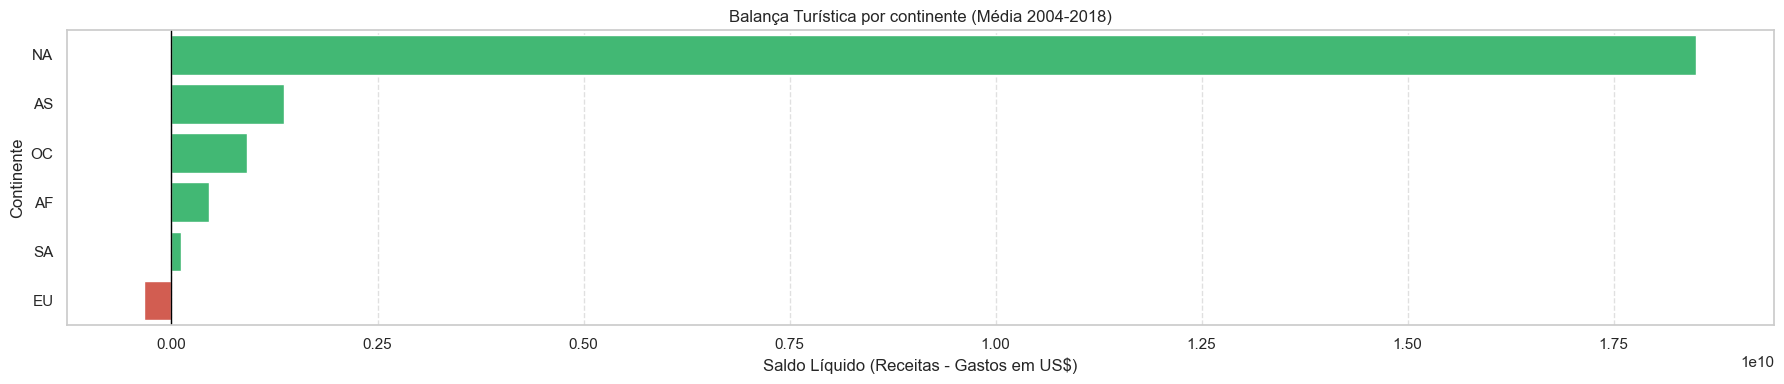

In [427]:
df_regiao = df.groupby('Continente')[['Receipts', 'Expenditures']].mean().reset_index()

# Calculando saldo regional
df_regiao['Saldo'] = df_regiao['Receipts'] - df_regiao['Expenditures']
df_regiao = df_regiao.sort_values(by='Saldo', ascending=False)

plt.figure(figsize=(18, 4))
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in df_regiao['Saldo']]

sns.barplot(data=df_regiao, x='Saldo', y='Continente', palette=colors, hue='Continente', legend=False)

plt.axvline(0, color='black', linestyle='-', linewidth=1)
plt.title('Balança Turística por continente (Média 2004-2018)')
plt.xlabel('Saldo Líquido (Receitas - Gastos em US$)')
plt.ylabel('Continente')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

A América do Norte é a que melhor transforma turismo em lucro. Já a Europa faz o contrário, mesmo recebendo muitos turistas, seus moradores gastam ainda mais viajando para fora, ficando um pouco no prejuízo.

Dá pra ver que o dinheiro do turismo não está bem distribuído, poucos lugares concentram a maior parte do ganho.

### 7 Impacto de Receitas e chegadas de acordo com o IncomeGroup

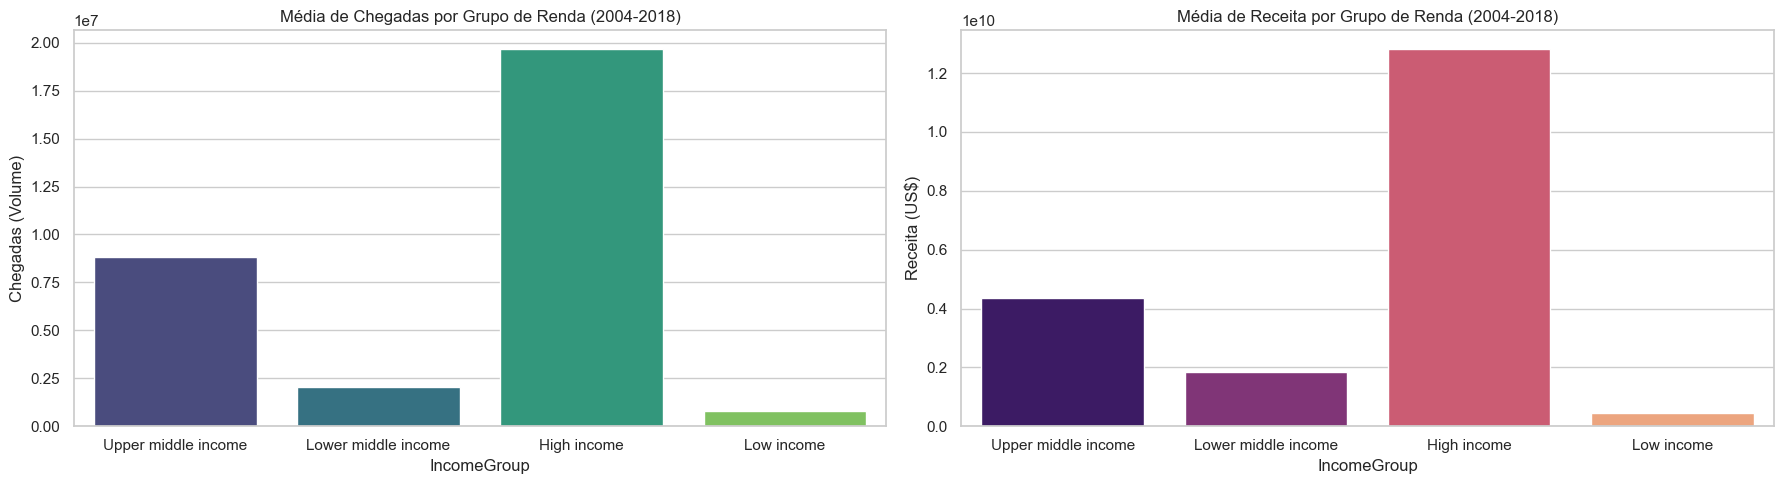

In [444]:
# Calcular a média do período por País e seu IncomeGroup
df_income = df.groupby(['País', 'IncomeGroup'])[['Arrivals', 'Receipts']].mean().reset_index()

# Países com valor baixo nesta métrica podem ser considerados "mais baratos"
df_income['Receita_por_Turista'] = df_income['Receipts'] / df_income['Arrivals']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))

# Volume de Turistas por Incomegroup
sns.barplot(data=df_income, x='IncomeGroup', y='Arrivals', hue='IncomeGroup', 
            palette='viridis', ax=ax1, errorbar=None, legend=False)
ax1.set_title('Média de Chegadas por Grupo de Renda (2004-2018)')
ax1.set_ylabel('Chegadas (Volume)')

# Receita Gerada por IncomeGroup
sns.barplot(data=df_income, x='IncomeGroup', y='Receipts', hue='IncomeGroup', 
            palette='magma', ax=ax2, errorbar=None, legend=False)
ax2.set_title('Média de Receita por Grupo de Renda (2004-2018)')
ax2.set_ylabel('Receita (US$)')

plt.tight_layout()
plt.show()

Podemos uma relçao em que quanto mais ricos os países mais receitas e turistas eles recebem.

### 8 Países com maiores crescimentos em chegadas e receitas

Vamos pegar 2 intervalos de 2004-2008 e 2014-2018 para calcular a média e ver os top 10 países onde houve a maior diferença de receita e chegada.

*Visualize os gráficos abaixo:*

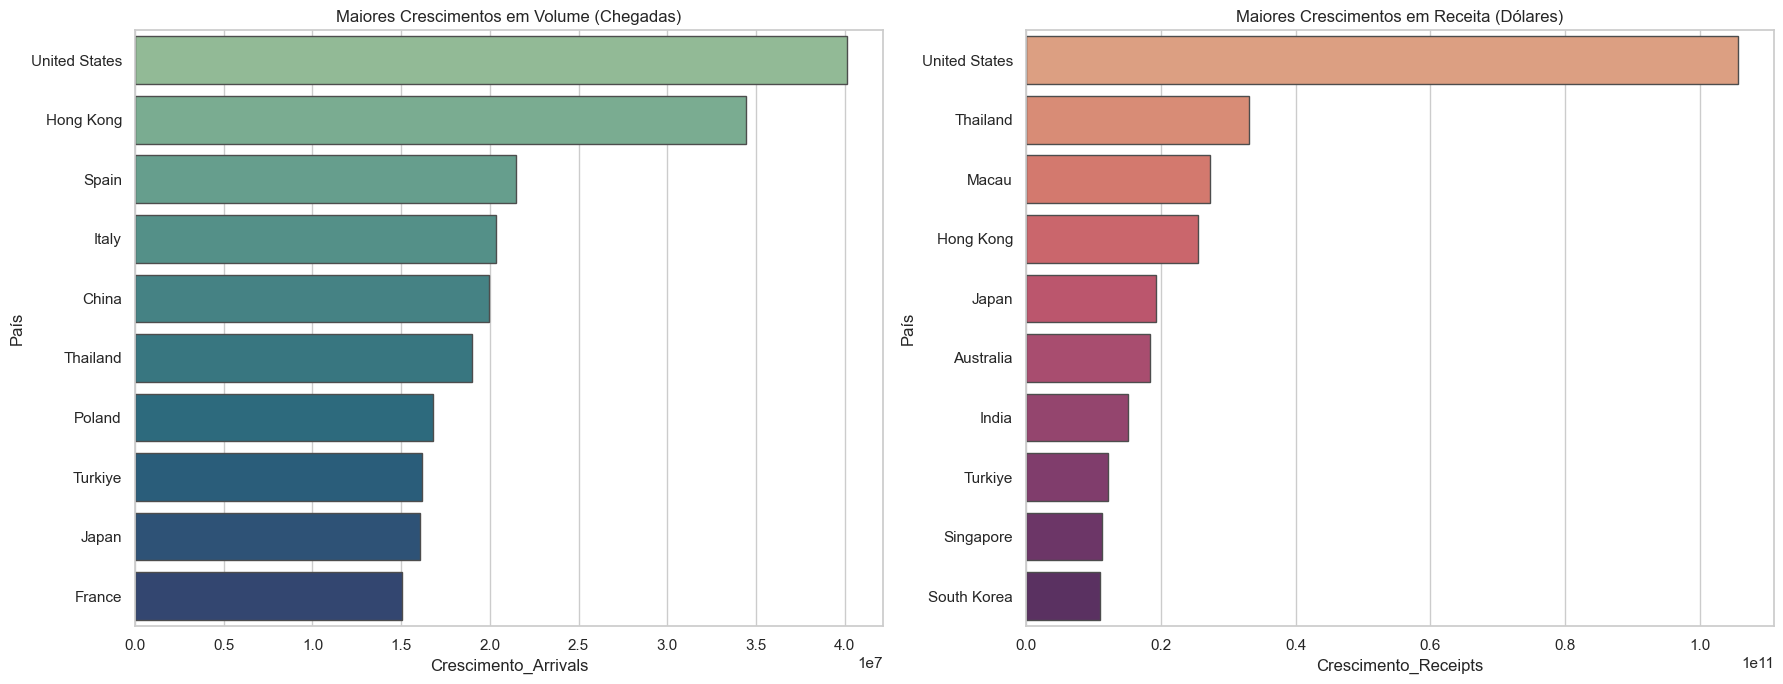

--- Análise de Performance de Crescimento ---
Correlação entre crescer em turistas e crescer em receita: 0.7625


In [473]:
# calulando as medias por periodo
df_inicio = df[df['Ano'].between(2004, 2008)].groupby('País')[['Arrivals', 'Receipts']].mean()
df_fim = df[df['Ano'].between(2014, 2018)].groupby('País')[['Arrivals', 'Receipts']].mean()

# crescimento absoluto (Diferença entre o fim e o início)
df_crescimento = (df_fim - df_inicio).reset_index()
df_crescimento.columns = ['País', 'Crescimento_Arrivals', 'Crescimento_Receipts']

# top 10 em arrivals e receipts
top_cresc_arrivals = df_crescimento.nlargest(10, 'Crescimento_Arrivals')
top_cresc_receipts = df_crescimento.nlargest(10, 'Crescimento_Receipts')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(data=top_cresc_arrivals, edgecolor='0.3' , linewidth=1, x='Crescimento_Arrivals', y='País', hue='País', palette='crest', ax=ax1, legend=False)
ax1.set_title('Maiores Crescimentos em Volume (Chegadas)')

sns.barplot(data=top_cresc_receipts, edgecolor='0.3' , linewidth=1, x='Crescimento_Receipts', y='País', hue='País', palette='flare', ax=ax2, legend=False)
ax2.set_title('Maiores Crescimentos em Receita (Dólares)')

plt.tight_layout()
plt.show()

#Adicione edgecolor='0.3' e linewidth=1 dentro do sns.barplot.
#Substitua Blues_r por crest ou mako_r.
#Substitua Oranges_r por flare ou rocket_r.


# Correlação entre crescer em gente e crescer em dinheiro
corr_crescimento = df_crescimento['Crescimento_Arrivals'].corr(df_crescimento['Crescimento_Receipts'])

print(f"--- Análise de Performance de Crescimento ---")
print(f"Correlação entre crescer em turistas e crescer em receita: {corr_crescimento:.4f}")


Os Estados Unidos se destacam muito, liderando com folga tanto no aumento de turistas quanto no crescimento de receita.

Mas tem um detalhe importante: países como França e Espanha recebem muita gente, mas não crescem tanto em dinheiro quanto outros lugares. Já destinos como Tailândia, Macau e Austrália conseguem gerar mais receita mesmo com menos turistas, eles ganham mais por visitante.

No geral, alguns países da Ásia, como Japão, Hong Kong e Turquia, conseguem equilibrar bem as duas coisas: atraem mais turistas e, ao mesmo tempo, aumentam bastante a receita.

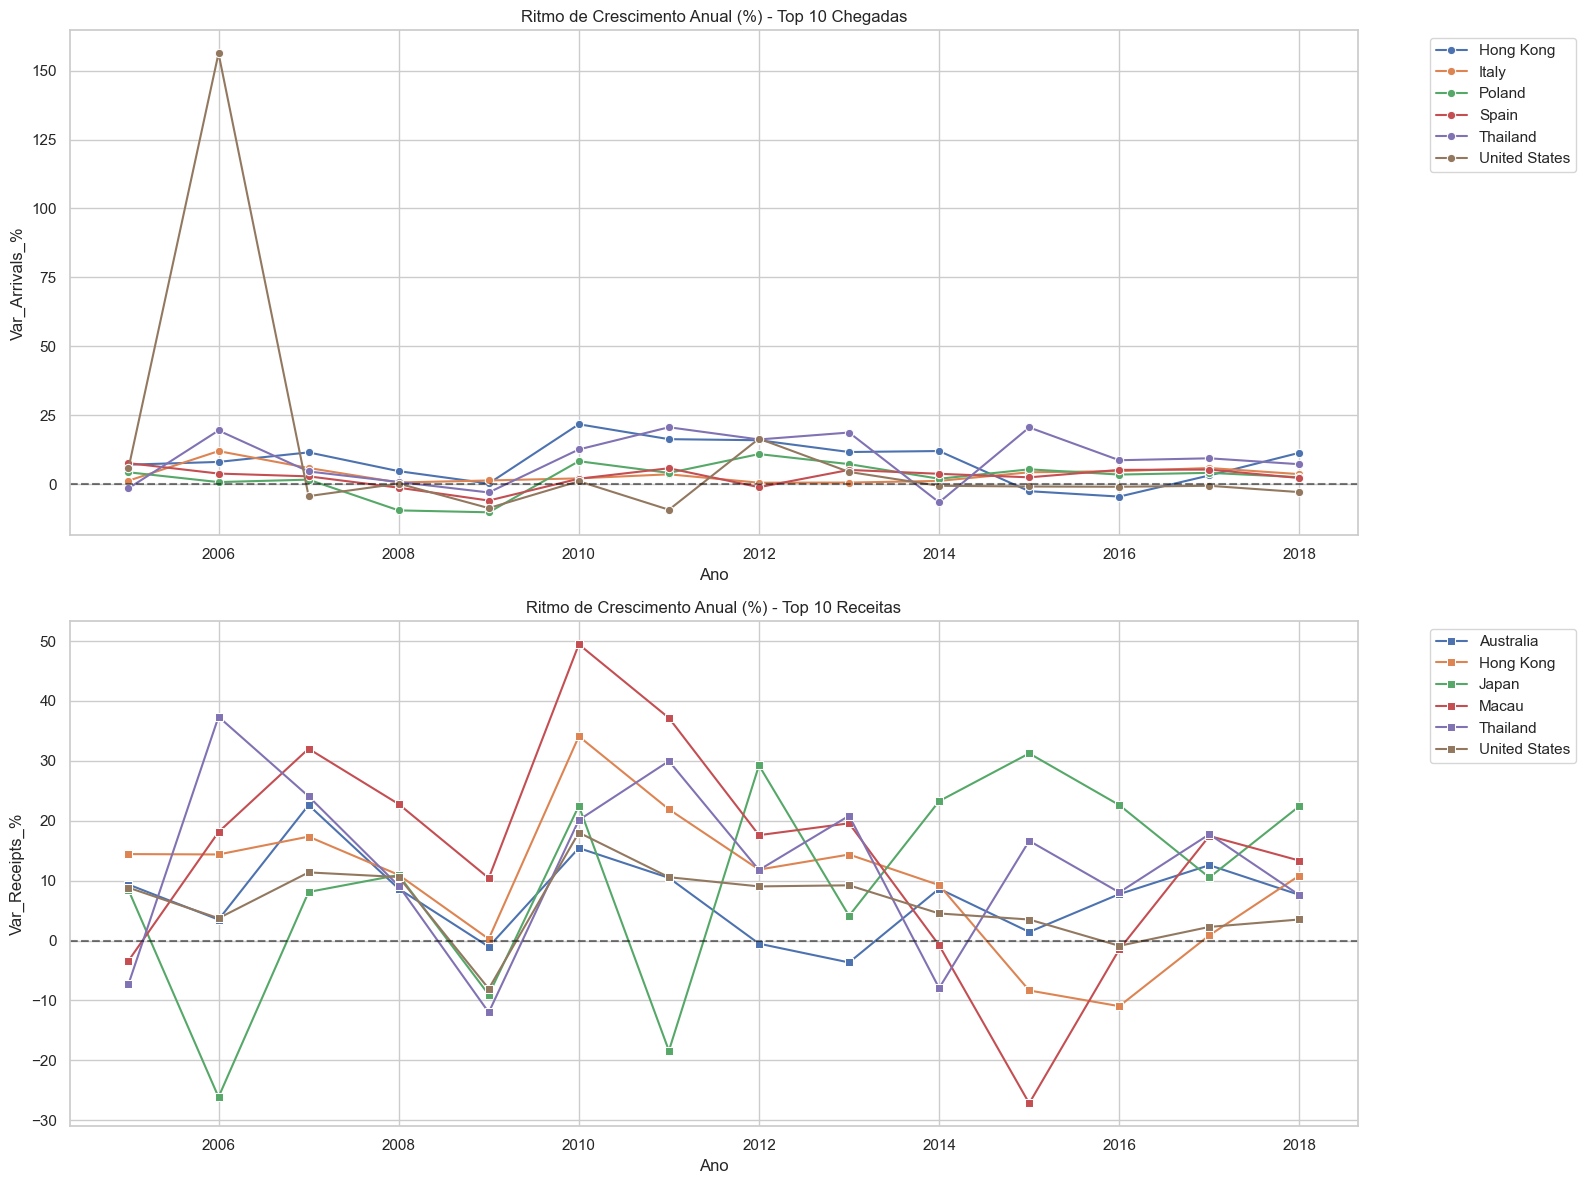

In [474]:
# pegando media dos intervalos
df_inicio = df[df['Ano'].between(2004, 2009)].groupby('País')[['Arrivals', 'Receipts']].mean()
df_fim = df[df['Ano'].between(2013, 2018)].groupby('País')[['Arrivals', 'Receipts']].mean()

df_crescimento = (df_fim - df_inicio).reset_index()
df_crescimento.columns = ['País', 'Crescimento_Arrivals', 'Crescimento_Receipts']

# Pegamos as listas de países Top 10
paises_top_arrivals = df_crescimento.nlargest(6, 'Crescimento_Arrivals')['País'].tolist()
paises_top_receipts = df_crescimento.nlargest(6, 'Crescimento_Receipts')['País'].tolist()

# calculo de porcentagem ano a ano
df_evolucao = df.sort_values(['País', 'Ano']).copy()

# Cálculo da variação percentual anual: ((V_atual - V_anterior) / V_anterior) * 100
df_evolucao['Var_Arrivals_%'] = df_evolucao.groupby('País')['Arrivals'].pct_change() * 100
df_evolucao['Var_Receipts_%'] = df_evolucao.groupby('País')['Receipts'].pct_change() * 100


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

# Gráfico 1: Evolução dos Top 10 em Chegadas
df_plot_arr = df_evolucao[df_evolucao['País'].isin(paises_top_arrivals)]
sns.lineplot(data=df_plot_arr, x='Ano', y='Var_Arrivals_%', hue='País', marker='o', ax=ax1)
ax1.set_title('Ritmo de Crescimento Anual (%) - Top 10 Chegadas')
ax1.axhline(0, color='black', linestyle='--', alpha=0.5)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Gráfico 2: Evolução dos Top 10 em Receita
df_plot_rec = df_evolucao[df_evolucao['País'].isin(paises_top_receipts)]
sns.lineplot(data=df_plot_rec, x='Ano', y='Var_Receipts_%', hue='País', marker='s', ax=ax2)
ax2.set_title('Ritmo de Crescimento Anual (%) - Top 10 Receitas')
ax2.axhline(0, color='black', linestyle='--', alpha=0.5)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Nesse gráfico fica claro como a crise de 2009 afetou o turismo. Perceba também, como os Estados Unidos aumentou em 2006 se consolidando em um dos maiores pontos turisticos do mundo, mas o numero de receita não creceu porporcionalmente. 

Alguns casos chamam atenção, como Macau e Japão, que tem grandes altos e baixos na receita, mostrando como o dinheiro do turismo pode ser instável. No fim, o principal ponto é que receber muitos turistas não garante ganhos consistentes, o faturamento depende de vários fatores, como economia global, câmbio e quanto cada visitante está disposto a gastar.

### 9 Países estagnados

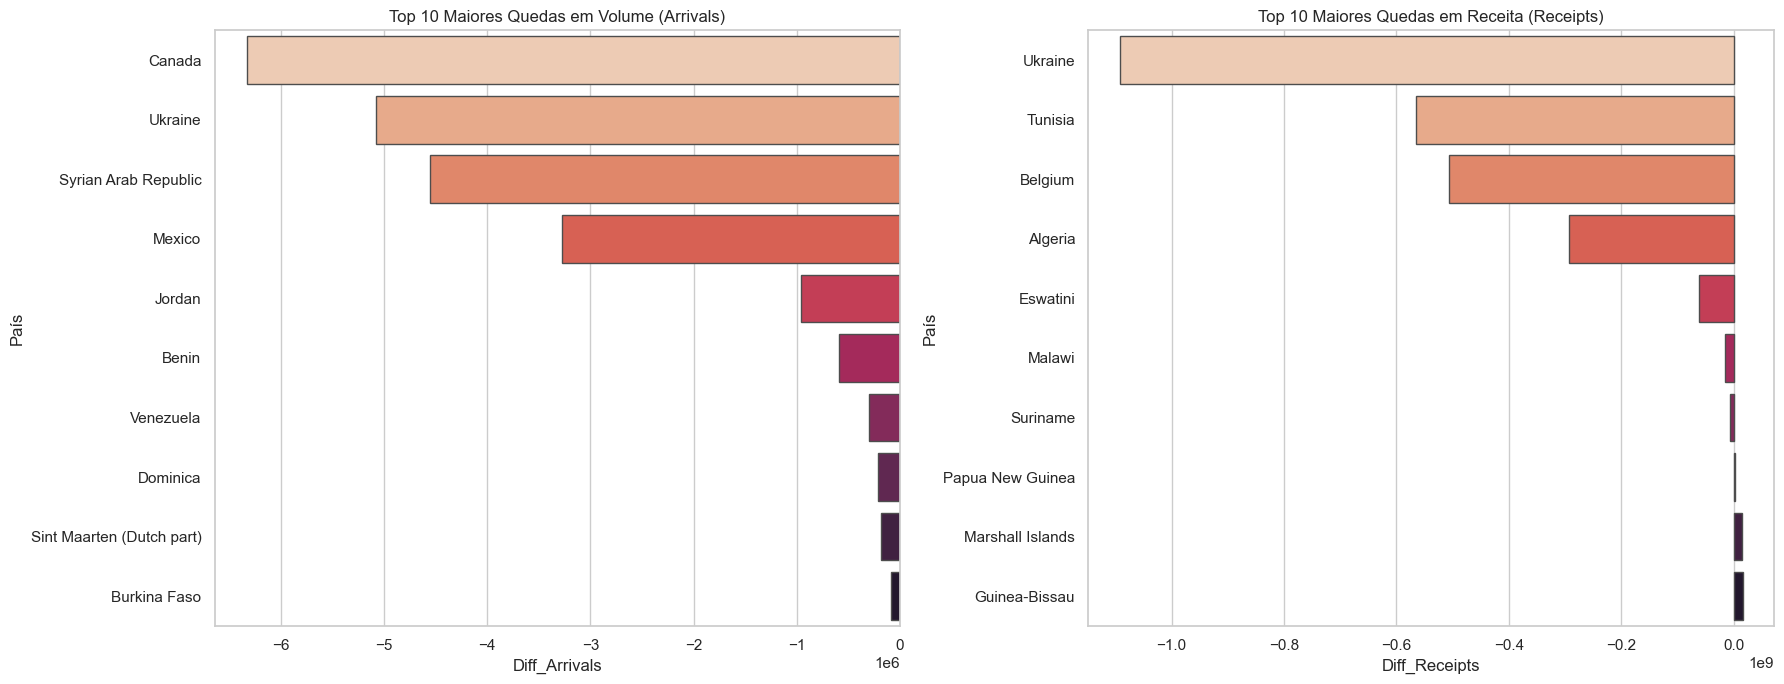

--- Relatório de Estagnação e Declínio ---
Quantidade de países que perderam receita no período: 7
Países com 'Turismo Ineficiente' (Mais gente, menos dinheiro): 5

Exemplos de países no descompasso:
         País  Diff_Arrivals  Diff_Receipts
1     Algeria      1215500.0   -293250000.0
14    Belgium      2023500.0   -507500000.0
50   Eswatini       128000.0    -61400000.5
91     Malawi       421500.0    -16500000.0
154   Tunisia      1487500.0   -565000000.0


In [ ]:
# Calculando médias dos periodos
df_inicio = df[df['Ano'].between(2004, 2005)].groupby('País')[['Arrivals', 'Receipts']].mean()
df_fim = df[df['Ano'].between(2017, 2018)].groupby('País')[['Arrivals', 'Receipts']].mean()

# variação absoluta (fim - inicio)
df_variacao = (df_fim - df_inicio).reset_index()
df_variacao.columns = ['País', 'Diff_Arrivals', 'Diff_Receipts']

# Pegando os 10 maiores declinios
piores_arrivals = df_variacao.nsmallest(10, 'Diff_Arrivals')
piores_receipts = df_variacao.nsmallest(10, 'Diff_Receipts')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(data=piores_arrivals, edgecolor='0.3', linewidth=1, x='Diff_Arrivals', y='País', hue='País', palette='rocket_r', ax=ax1, legend=False)
ax1.set_title('Top 10 Maiores Quedas em Volume (Arrivals)')

sns.barplot(data=piores_receipts, edgecolor='0.3', linewidth=1, x='Diff_Receipts', y='País', hue='País', palette='rocket_r', ax=ax2, legend=False)
ax2.set_title('Top 10 Maiores Quedas em Receita (Receipts)')

plt.tight_layout()
plt.show()

#Adicione edgecolor='0.3' e linewidth=1 dentro do sns.barplot.
#Substitua Blues_r por crest ou mako_r.
#Substitua Oranges_r por flare ou rocket_r.

O gráfico mostra que nem todos os países cresceram no turismo, alguns tiveram quedas fortes ao longo dos anos. Casos como Ucrânia e Síria deixam isso bem claro: conflitos e crises internas afetam diretamente o turismo, reduzindo tanto o número de visitantes quanto o dinheiro gerado.

Também aparecem situações curiosas, como Canadá e México, que perderam muitos turistas, mas nem sempre tiveram perdas financeiras na mesma proporção. Já países como Tunísia e Bélgica perderam mais em receita, o que indica que os turistas passaram a gastar menos.

### 10 Distribuição global do total de arrivals e receipts (2004-2018)

Vejamos como cresceu o turismo global no período de 2004 a 2018

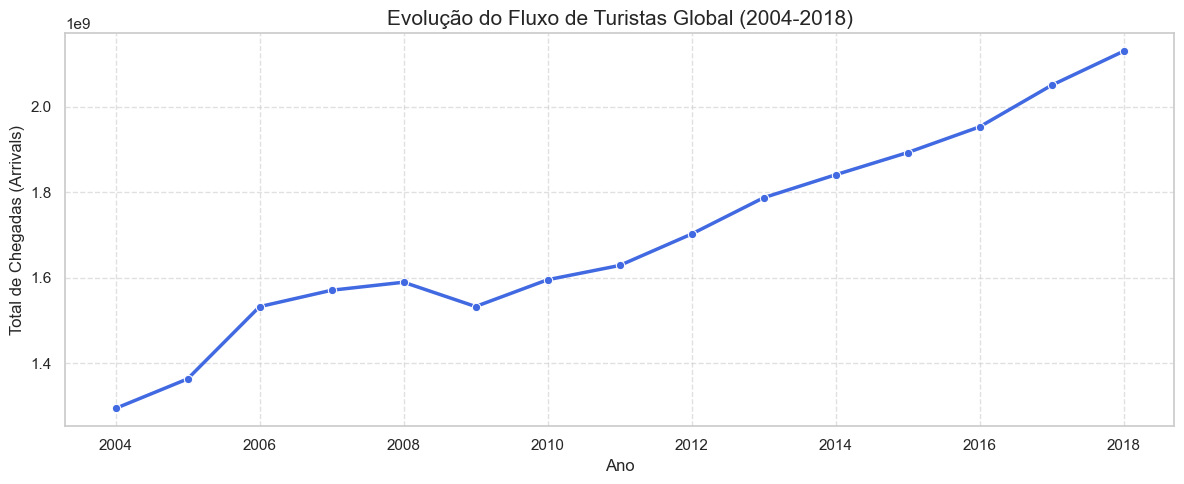

Crescimento acumulado no período: 64.56%


In [480]:
# somando o total de arrivals
df_anual_total = df.groupby('Ano')['Arrivals'].sum().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=df_anual_total, x='Ano', y='Arrivals', marker='o', color='royalblue', linewidth=2.5)

plt.title('Evolução do Fluxo de Turistas Global (2004-2018)', fontsize=15)
plt.ylabel('Total de Chegadas (Arrivals)')
plt.xlabel('Ano')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# calculo global de crescimento total em %
total_2004 = df_anual_total.iloc[0]['Arrivals']
total_2018 = df_anual_total.iloc[-1]['Arrivals']
crescimento_total = ((total_2018 - total_2004) / total_2004) * 100

print(f"Crescimento acumulado no período: {crescimento_total:.2f}%")

Entre 2004 e 2018, o turismo mundial cresceu bastante. Foi um aumento quase contínuo, com uma única queda em 2009 por causa da crise financeira global.

Mesmo assim, a recuperação veio rápido e o crescimento continuou forte nos anos seguintes. No geral, isso mostra que o turismo se tornou uma atividade cada vez maior no mundo, crescendo de forma consistente apesar de crises pontuais.

Agora vejamos a receita total global entre 2004 a 2018

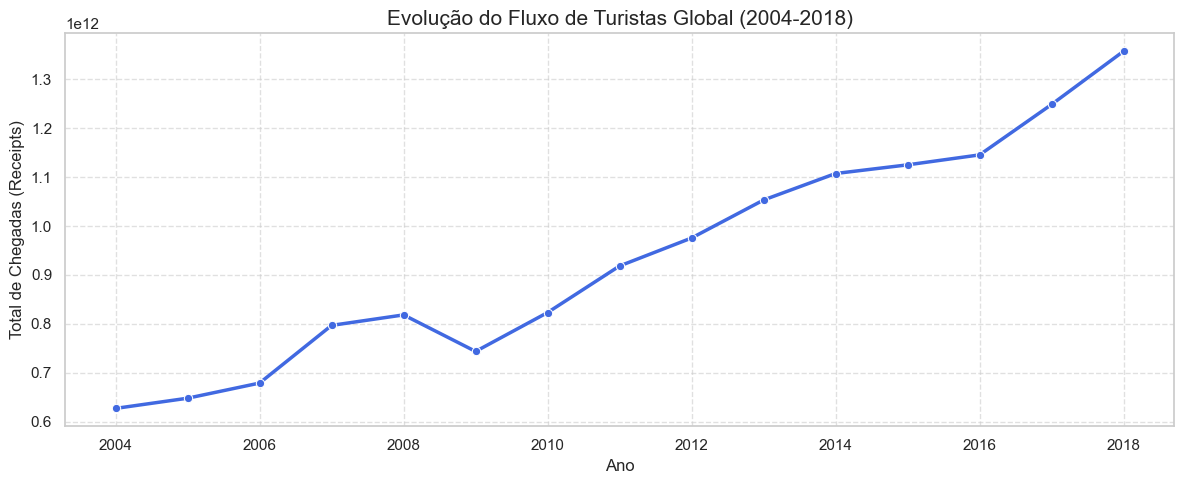

Crescimento acumulado no período: 116.38%


In [481]:
# agrupando por receita
df_anual_total = df.groupby('Ano')['Receipts'].sum().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=df_anual_total, x='Ano', y='Receipts', marker='o', color='royalblue', linewidth=2.5)

plt.title('Evolução do Fluxo de Turistas Global (2004-2018)', fontsize=15)
plt.ylabel('Total de Chegadas (Receipts)')
plt.xlabel('Ano')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# calculando crescimento em %
total_2004 = df_anual_total.iloc[0]['Receipts']
total_2018 = df_anual_total.iloc[-1]['Receipts']
crescimento_total = ((total_2018 - total_2004) / total_2004) * 100

print(f"Crescimento acumulado no período: {crescimento_total:.2f}%")

Assim como aconteceu com o número de chegadas houve um aumento quase linear, com ressalvas para a queda em 2009.

### Concentração de ríquezas

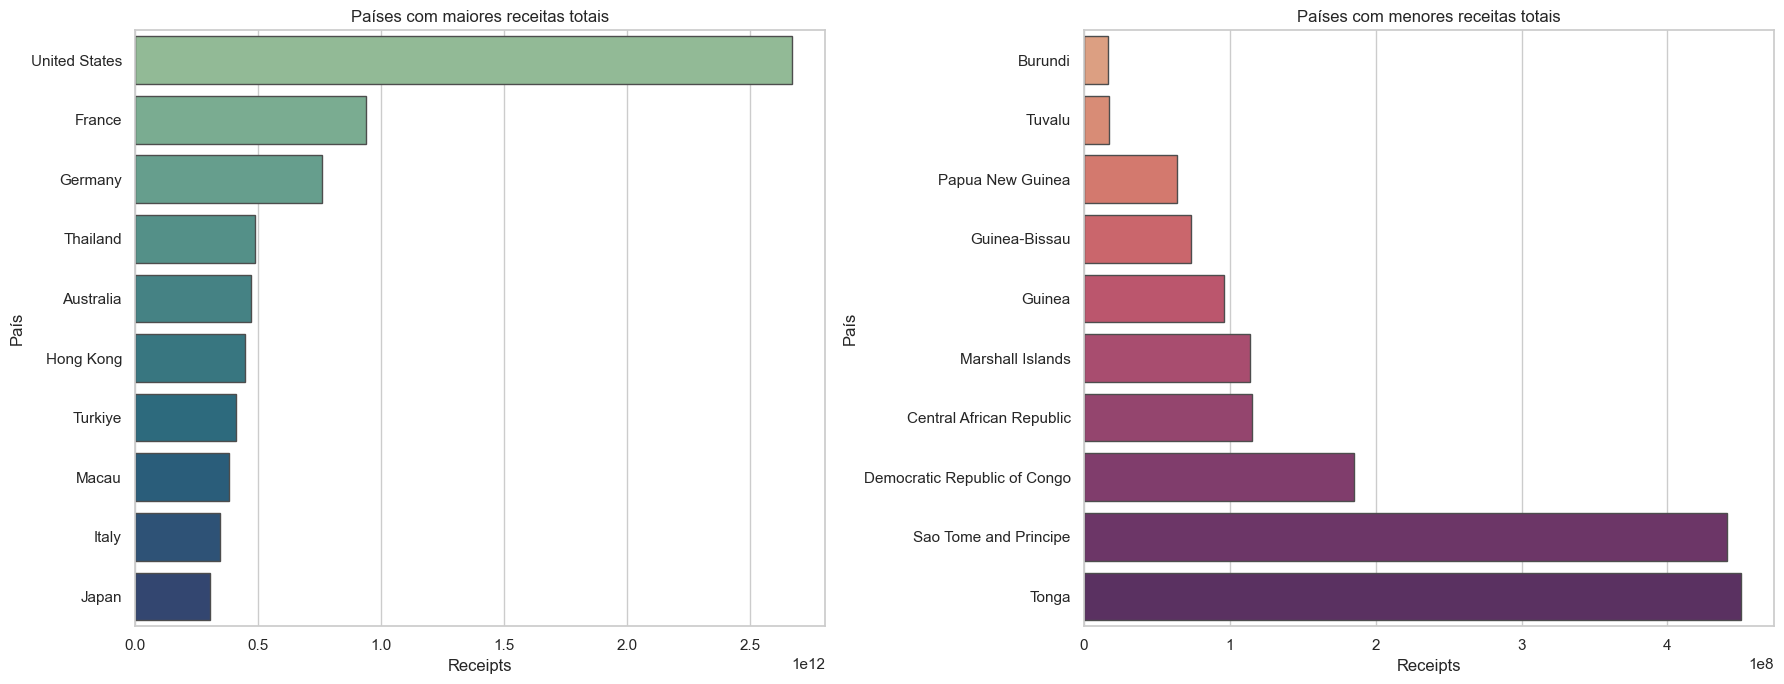

In [ ]:
df_receitas = df.groupby('País')[['Receipts']].sum().reset_index()
df_receitas = df_receitas[df_receitas['Receipts'] != 0]

top_maiores = df_receitas.nlargest(10, 'Receipts')
top_menores = df_receitas.nsmallest(10, 'Receipts')

# sharex=True -> compartilha a mesma proporção

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(data=top_maiores, edgecolor='0.3', linewidth=1, x='Receipts', y='País', palette='crest', ax=ax1)
ax1.set_title('Países com maiores receitas totais')

sns.barplot(data=top_menores, edgecolor='0.3', linewidth=1, x='Receipts', y='País', palette='flare', ax=ax2)
ax2.set_title('Países com menores receitas totais')

plt.tight_layout()
plt.show()

Os dados mostram uma diferença enorme no dinheiro gerado pelo turismo entre os países. Os Estados Unidos lideram com uma receita gigantesca, passando de trilhões de dólares, enquanto países como Burundi e Tuvalu ficam na casa dos milhões.

Na prática, isso significa que alguns poucos países concentram quase toda a riqueza do turismo. Enquanto grandes economias acumulam valores muito altos, países menores ficam com uma parte bem pequena, mostrando como o dinheiro do turismo é muito desigual no mundo.

### 12 Países com mais turistas que habitantes

Primeiro vejamos a distribuição de turistas por pessoa no histograma a seguir:

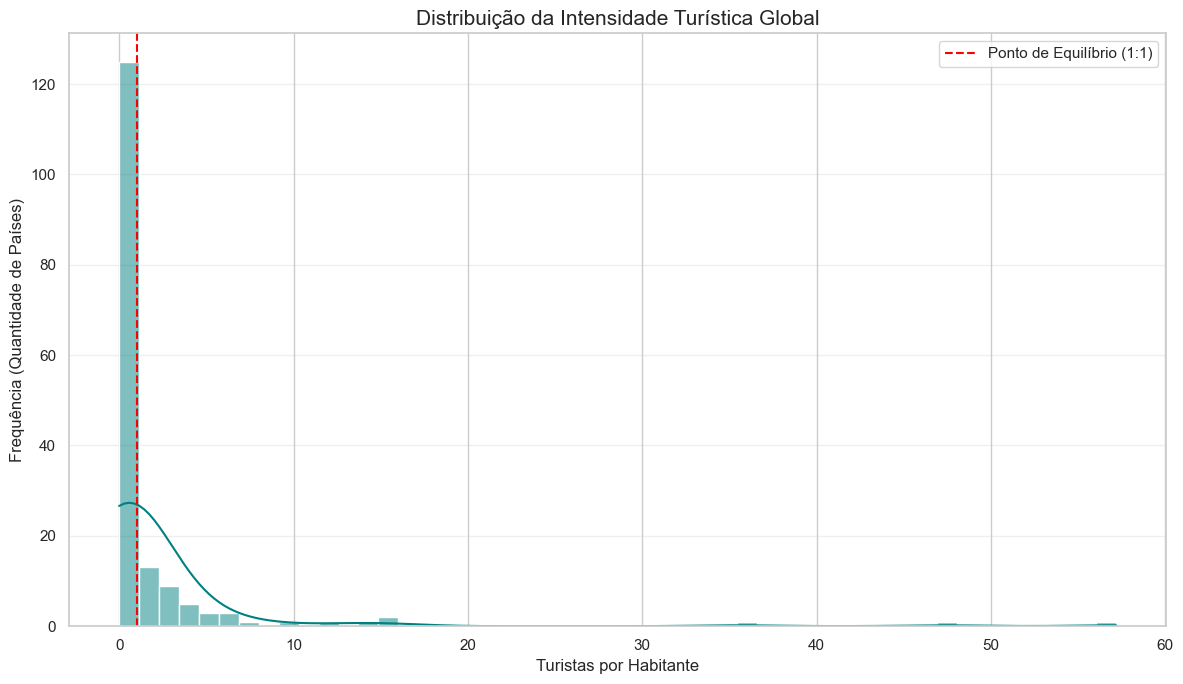

In [495]:
# Calculando media
df_hist = df.groupby('País')[['Arrivals', 'Population']].mean().reset_index()
df_hist['Turistas_por_Habitante'] = df_hist['Arrivals'] / df_hist['Population']

# histograma
plt.figure(figsize=(12, 7))
sns.histplot(df_hist['Turistas_por_Habitante'], bins=50, kde=True, color='teal')

plt.axvline(1, color='red', linestyle='--', label='Ponto de Equilíbrio (1:1)')
plt.title('Distribuição da Intensidade Turística Global', fontsize=15)
plt.xlabel('Turistas por Habitante')
plt.ylabel('Frequência (Quantidade de Países)')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Podemos obeservar que a grande maioria dos países possuem mais habitantes que turistas, ou seja, turistas por habitante < 1.

Obeservamos também que existem poucos países fora da curva, mas eles possuem até 60x mais turistas que população

**Vejamos agora o top 10 países onde isso acontece:**

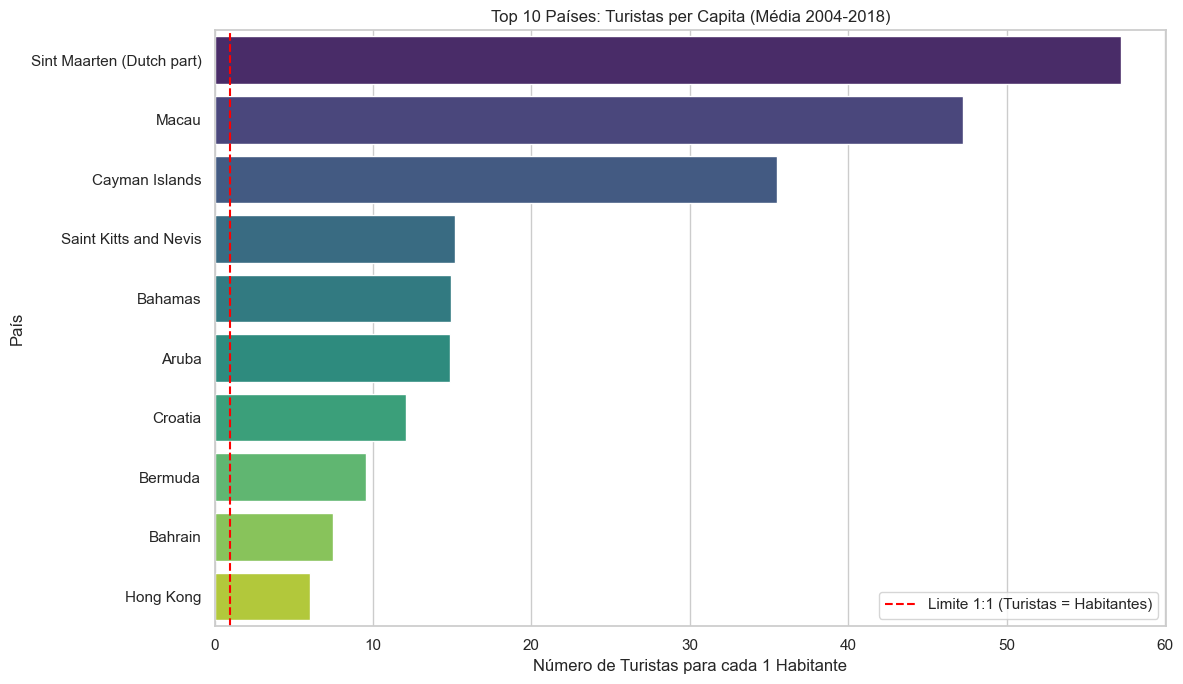

Total de países com mais turistas que habitantes: 45

Top 5 maiores densidades:
                          País  Turistas_por_Habitante
134  Sint Maarten (Dutch part)               57.179819
90                       Macau               47.213020
29              Cayman Islands               35.512075
126      Saint Kitts and Nevis               15.146795
9                      Bahamas               14.902565


In [497]:
# Se o resultado for > 1, o país recebe mais turistas que sua população total
df_pop = df.groupby('País')[['Arrivals', 'Population']].mean().reset_index()
df_pop['Turistas_por_Habitante'] = df_pop['Arrivals'] / df_pop['Population']

# filtra paises com mais turistas que habitantes
paises_mais_turistas = df_pop[df_pop['Turistas_por_Habitante'] > 1].sort_values('Turistas_por_Habitante', ascending=False)

# pega ao top 10 com maior intensidade turistica por habitante
plt.figure(figsize=(12, 7))
top_10_intensidade = df_pop.nlargest(10, 'Turistas_por_Habitante')

sns.barplot(data=top_10_intensidade, x='Turistas_por_Habitante', y='País', hue='País', palette='viridis', legend=False)

# Adicionando uma linha vertical no 1.0 para marcar o limite "1 turista por 1 habitante"
plt.axvline(1, color='red', linestyle='--', label='Limite 1:1 (Turistas = Habitantes)')

plt.title('Top 10 Países: Turistas per Capita (Média 2004-2018)')
plt.xlabel('Número de Turistas para cada 1 Habitante')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Total de países com mais turistas que habitantes: {len(paises_mais_turistas)}")
print(f"\nTop 5 maiores densidades:")
print(paises_mais_turistas[['País', 'Turistas_por_Habitante']].head(5))

O gráfico mostra lugares onde o número de turistas é muito maior que o de moradores. Em alguns casos, como Sint Maarten, chegam a ser dezenas de turistas para cada pessoa que vive lá, mostrando um turismo extremamente intenso.

No geral, todos os países citados dependem muito do turismo. Lugares como Aruba e Bahamas recebem muito mais visitantes do que sua população, o que indica que possivelmente a estrutura desses destinos é voltada principalmente para atender turistas, e não só os moradores.

### 13 Análises de extremos

Veremos abaixo como a média de receipts, arrivals e expenditures estão distribuidos no intervalo de 2004 a 2018

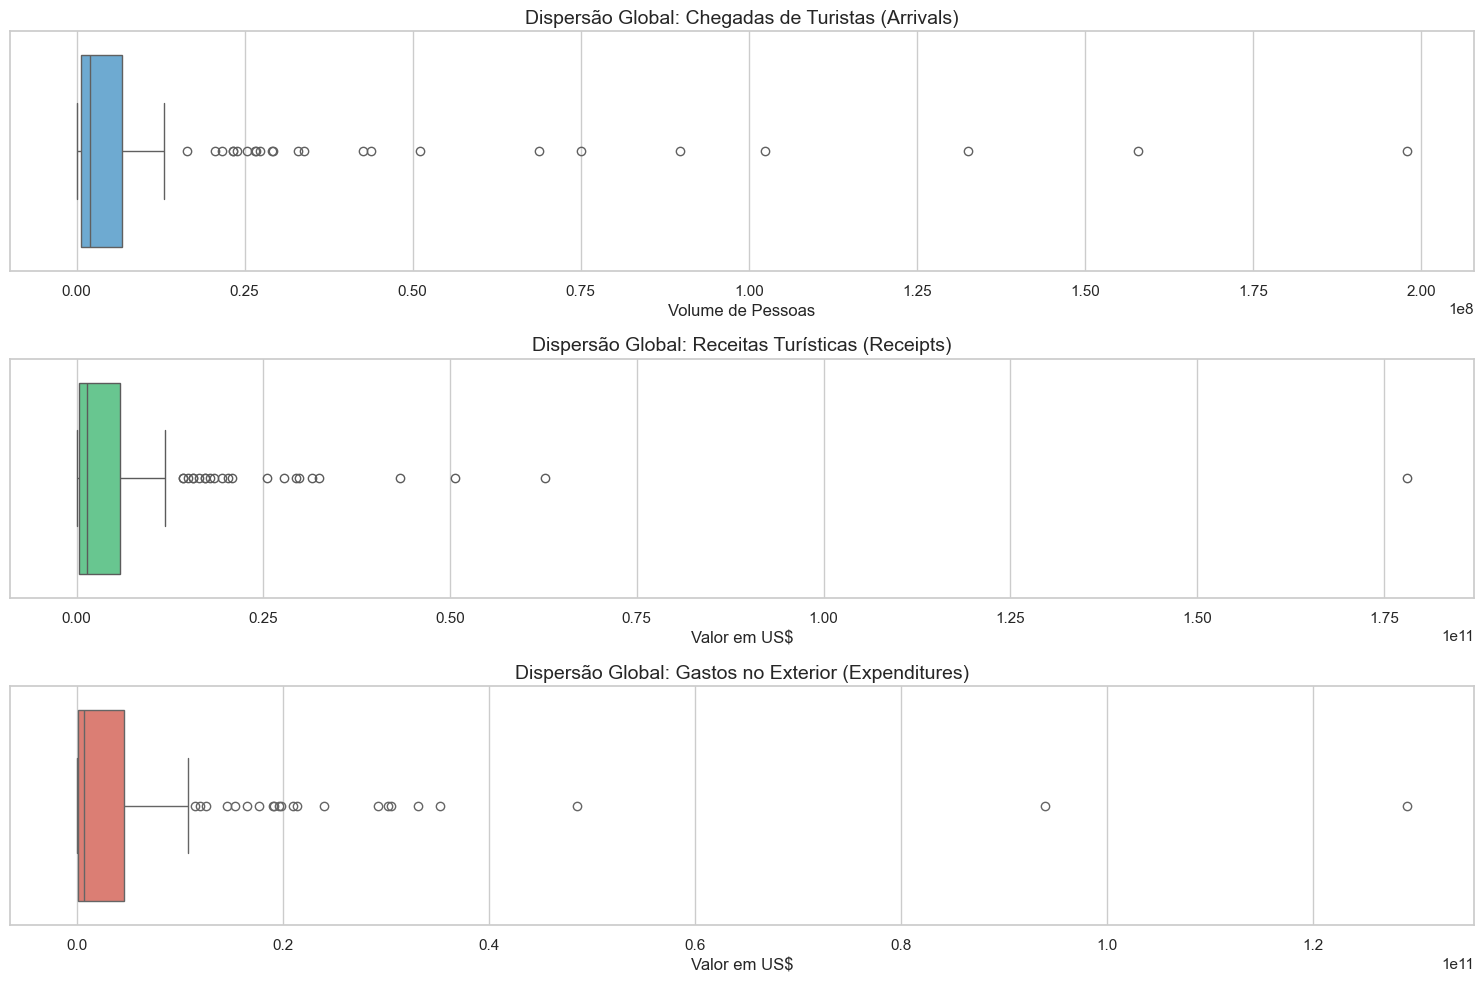

In [498]:
# pegando media
df_extremos = df.groupby('País')[['Receipts', 'Arrivals', 'Expenditures']].mean().reset_index()

# montando boxplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 10))

# Boxplot de Arrivals
sns.boxplot(data=df_extremos, x='Arrivals', ax=ax1, color='#5DADE2', fliersize=6)
ax1.set_title('Dispersão Global: Chegadas de Turistas (Arrivals)', fontsize=14)
ax1.set_xlabel('Volume de Pessoas')

# Boxplot de Receipts
sns.boxplot(data=df_extremos, x='Receipts', ax=ax2, color='#58D68D', fliersize=6)
ax2.set_title('Dispersão Global: Receitas Turísticas (Receipts)', fontsize=14)
ax2.set_xlabel('Valor em US$')

# Boxplot de Expenditures
sns.boxplot(data=df_extremos, x='Expenditures', ax=ax3, color='#EC7063', fliersize=6)
ax3.set_title('Dispersão Global: Gastos no Exterior (Expenditures)', fontsize=14)
ax3.set_xlabel('Valor em US$')

plt.tight_layout()
plt.show()

Os gráficos mostram que o turismo mundial é muito desigual. A maioria dos países aparece concentrada em valores baixos de turistas, receitas e gastos, enquanto poucos países ficam bem acima do resto. Esses poucos “gigantes” puxam os números para cima e dão a impressão de que o turismo global é maior do que realmente é para a maioria.

Isso deixa claro que o dinheiro e o fluxo de turistas estão concentrados em poucos lugares. Enquanto alguns países chegam a movimentar mais de 100 bilhões de dólares, a maior parte não chega nem perto disso.

**Percebemos alguns *outliers* superiores nos 3 boxplots, abaixo veremos quem são eles:**

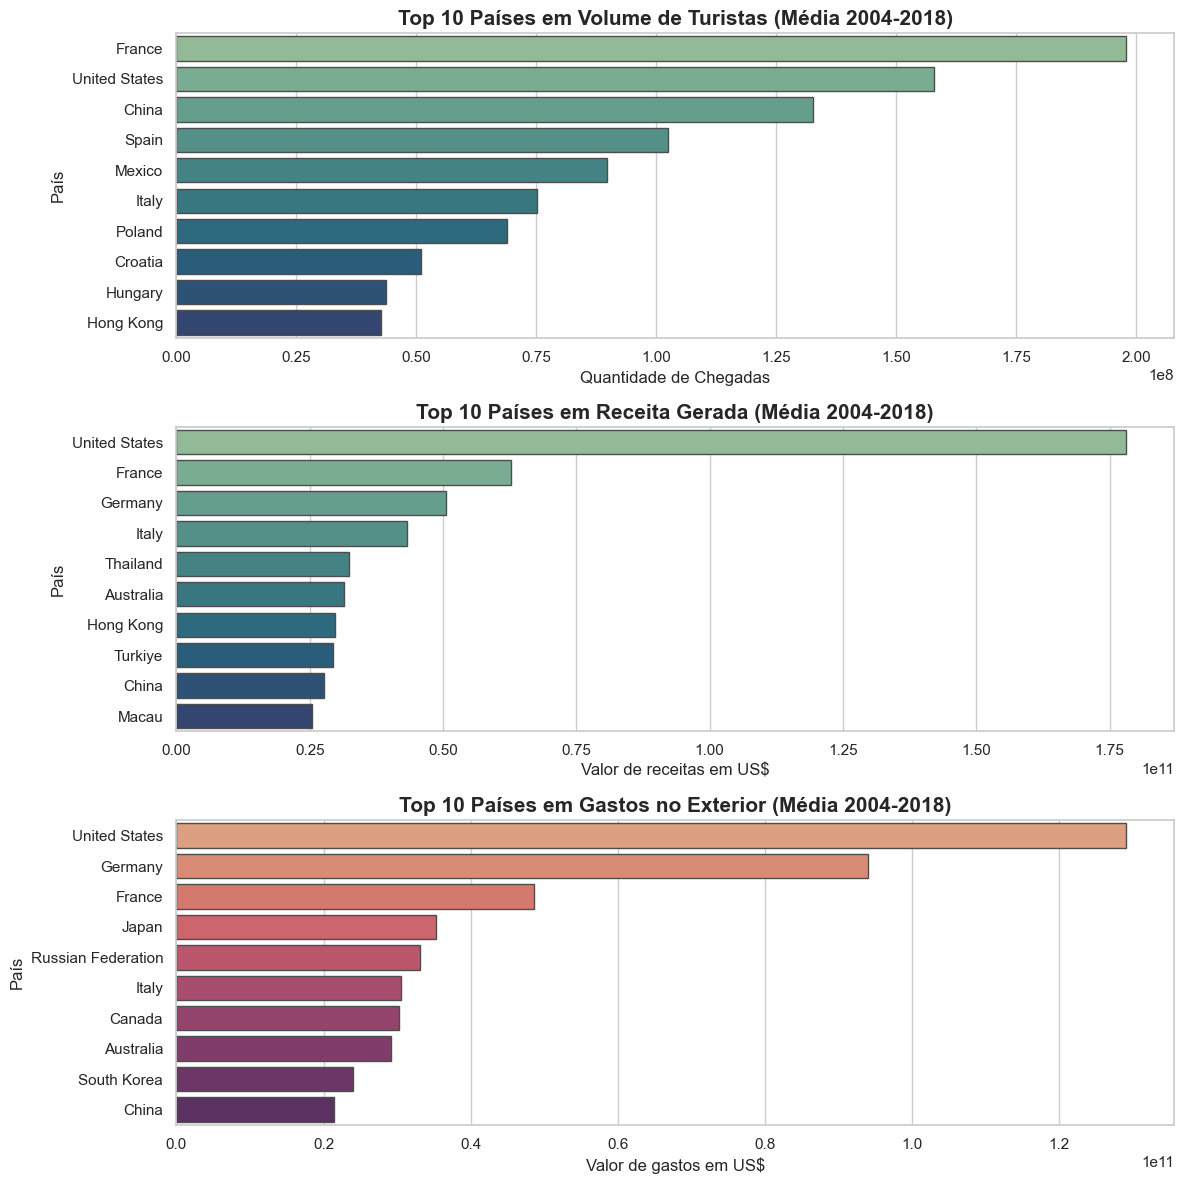

In [502]:
df_tops = df.groupby('País')[['Arrivals', 'Receipts', 'Expenditures']].mean().reset_index()

# criando 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12))

def plot_top10(coluna, titulo, paleta, eixo, label_x):
    top10 = df_tops.nlargest(10, coluna)
    sns.barplot(data=top10, edgecolor='0.3', linewidth=1, x=coluna, y='País', hue='País', palette=paleta, ax=eixo, legend=False)
    eixo.set_title(titulo, fontsize=15, fontweight='bold')
    eixo.set_xlabel(label_x)
    eixo.set_ylabel('País')

# Top 10 Arrivals (Volume)
plot_top10('Arrivals', 'Top 10 Países em Volume de Turistas (Média 2004-2018)', 'crest', ax1, 'Quantidade de Chegadas')

# Top 10 Receipts (Receita)
plot_top10('Receipts', 'Top 10 Países em Receita Gerada (Média 2004-2018)', 'crest', ax2, 'Valor de receitas em US$')

# Top 10 Expenditures (Gastos)
plot_top10('Expenditures', 'Top 10 Países em Gastos no Exterior (Média 2004-2018)', 'flare', ax3, 'Valor de gastos em US$')

#Adicione edgecolor='0.3' e linewidth=1 dentro do sns.barplot.
#Substitua Blues_r por crest ou mako_r.
#Substitua Oranges_r por flare ou rocket_r.
plt.tight_layout()
plt.show()

O painel mostra que o turismo no mundo tem dois tipos de destaque: países que recebem muita gente e países que ganham muito dinheiro com isso. A França lidera em número de turistas, mas os Estados Unidos ficam na frente quando o assunto é receita, mostrando que conseguem ganhar mais por visitante.

Quando olhamos para os gastos, Estados Unidos e Alemanha aparecem como os que mais gastam no exterior, movimentando o turismo global. Outros países como Japão e Coreia do Sul também gastam bastante, mesmo sem receber tantos turistas. No fim, fica claro que poucos países dominam o setor, seja atraindo visitantes ou movimentando grandes quantias de dinheiro.

### 14 Mudanças abruptas

Vejamos os principais países que tiveram as maiores variações em receitas e chegadas.

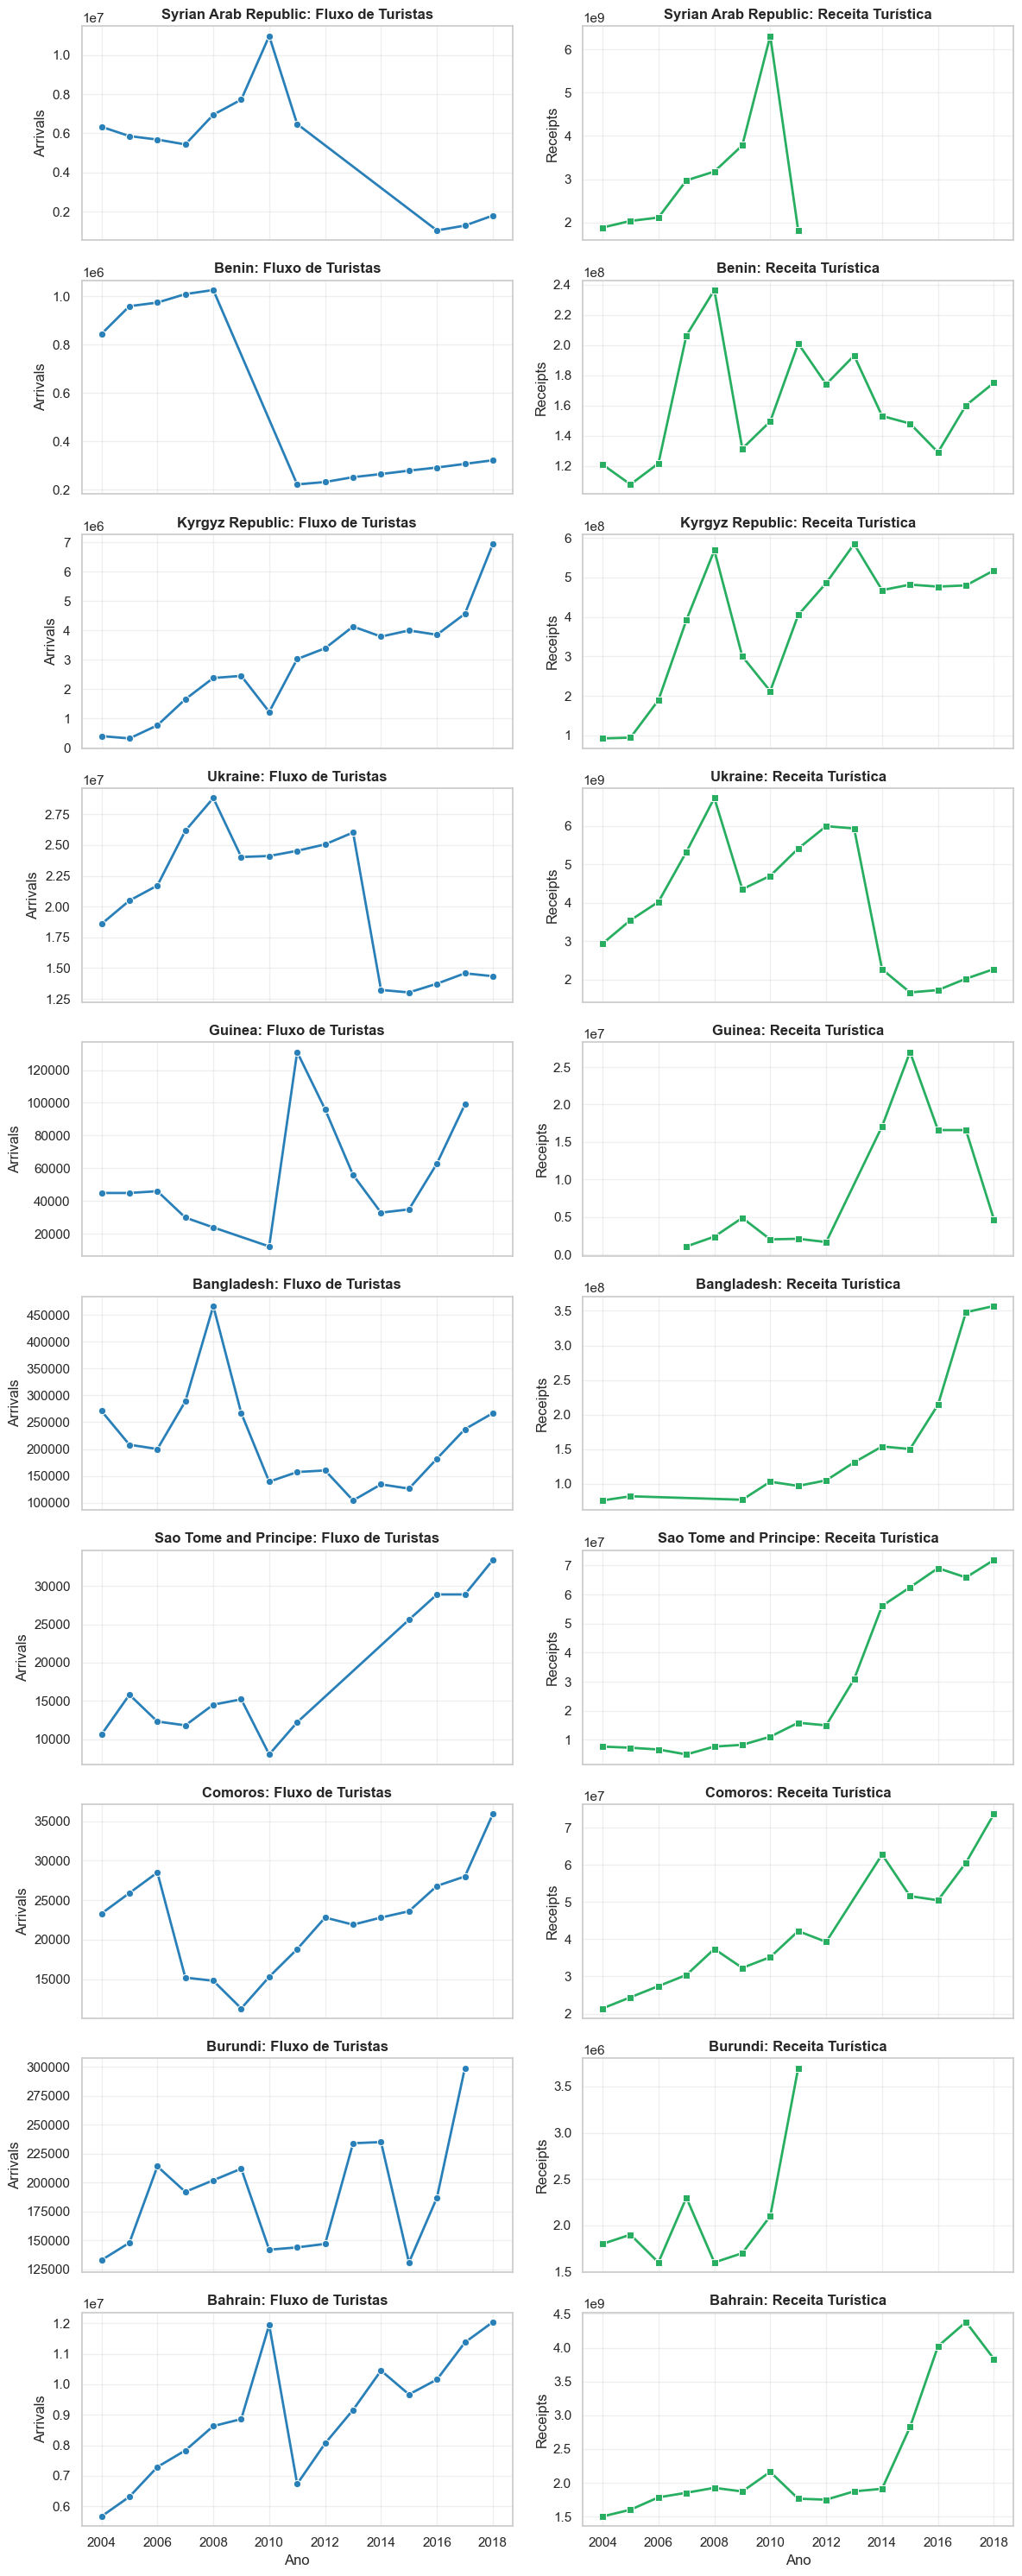

--- Comparação de Queda nas Crises ---
Syrian Arab Republic: Pior queda de Chegadas: -83.9% | Pior queda de Receita: -71.2%
Benin: Pior queda de Chegadas: -78.4% | Pior queda de Receita: -44.4%
Kyrgyz Republic: Pior queda de Chegadas: -50.1% | Pior queda de Receita: -47.3%
Ukraine: Pior queda de Chegadas: -49.2% | Pior queda de Receita: -61.8%
Guinea: Pior queda de Chegadas: -48.3% | Pior queda de Receita: -71.7%
Bangladesh: Pior queda de Chegadas: -47.9% | Pior queda de Receita: -6.1%
Sao Tome and Principe: Pior queda de Chegadas: -47.4% | Pior queda de Receita: -25.4%
Comoros: Pior queda de Chegadas: -46.7% | Pior queda de Receita: -17.8%
Burundi: Pior queda de Chegadas: -44.3% | Pior queda de Receita: -30.4%
Bahrain: Pior queda de Chegadas: -43.7% | Pior queda de Receita: -18.4%


In [ ]:
# calculando variações e identificar os países com maiores quedas (Choques)
df_var = df.sort_values(['País', 'Ano']).copy()
df_var['Var_Arr_%'] = df_var.groupby('País')['Arrivals'].pct_change() * 100
df_var['Var_Rec_%'] = df_var.groupby('País')['Receipts'].pct_change() * 100

# Selecionar os 10 países que tiveram os maiores tombos (em qualquer uma das métricas)
paises_crise = df_var.nsmallest(10, 'Var_Arr_%')['País'].unique()
df_plot = df[df['País'].isin(paises_crise)]

# criando uma coluna de arrivals e outra de receits
fig, axes = plt.subplots(len(paises_crise), 2, figsize=(12, 3 * len(paises_crise)), sharex=True)

for i, pais in enumerate(paises_crise):
    dados_pais = df_plot[df_plot['País'] == pais]
    
    # arrivals
    sns.lineplot(data=dados_pais, x='Ano', y='Arrivals', ax=axes[i, 0], marker='o', color='#2980b9', linewidth=2)
    axes[i, 0].set_title(f'{pais}: Fluxo de Turistas', fontweight='bold')
    axes[i, 0].grid(True, alpha=0.3)
    
    # receipts
    sns.lineplot(data=dados_pais, x='Ano', y='Receipts', ax=axes[i, 1], marker='s', color='#27ae60', linewidth=2)
    axes[i, 1].set_title(f'{pais}: Receita Turística', fontweight='bold')
    axes[i, 1].grid(True, alpha=0.3)

    # Adicionar anotação do ano de crise na primeira coluna
    ymin_arr = dados_pais['Arrivals'].min()
    ano_crise = dados_pais[dados_pais['Arrivals'] == ymin_arr]['Ano'].values[0]

plt.tight_layout()
plt.show()

# 3. Resumo de correlação de choque
print("--- Comparação de Queda nas Crises ---")
for pais in paises_crise:
    menor_var_arr = df_var[df_var['País'] == pais]['Var_Arr_%'].min()
    menor_var_rec = df_var[df_var['País'] == pais]['Var_Rec_%'].min()
    print(f"{pais}: Pior queda de Chegadas: {menor_var_arr:.1f}% | Pior queda de Receita: {menor_var_rec:.1f}%")

**Será que essas mudanças foram influênciadas por fatos históricos?**

*Peguemos alguns exemplos: Ucrânia, Siria e guine.*

A instabilidade política e os conflitos armados foram os principais responsáveis por transformar o cenário turístico nesses países: enquanto a Guiné (2011) viram aumentos pontuais impulsionados por transições democráticas e o câmbio favorável, a Síria e a Ucrânia sofreram colapsos severos devido à eclosão de guerras civis e perdas territoriais entre 2010 e 2014. Na Síria, o setor desmoronou com o início da violência em 2011, e na Ucrânia, a queda foi agravada pela perda da Crimeia, seu principal destino de lazer, e pelo risco aéreo gerado pelos confrontos no leste, provando que a segurança e a integridade territorial são pilares essenciais para a sustentabilidade do turismo internacional.

### 15 Como está o Brasil no meio disso tudo?

Vejamos como as receitas, gastos e chegadas se distribuem ao longo dos anos no Brasil:

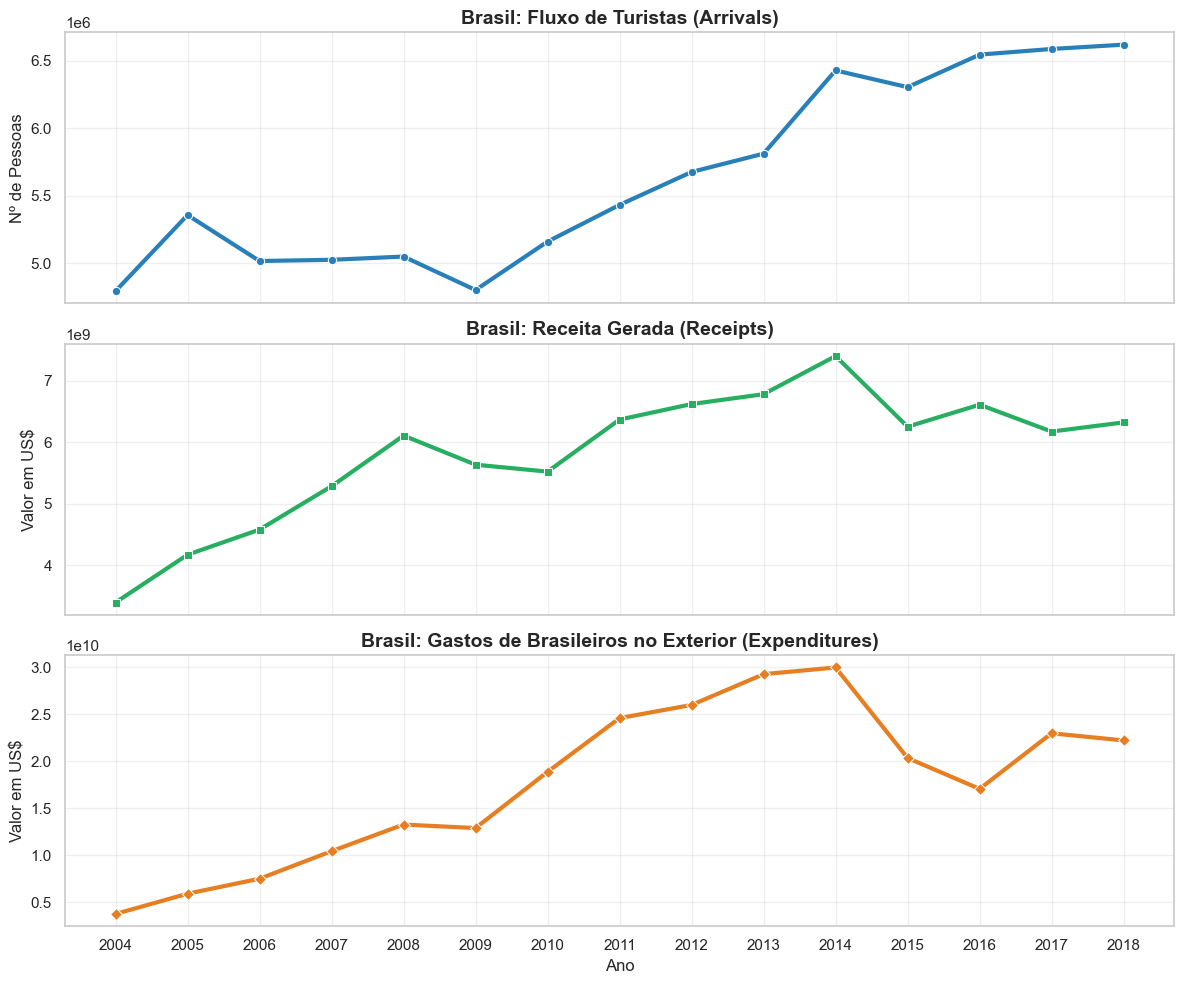

     Ano   Arrivals      Receipts  Expenditures
0   2004  4794000.0  3.389000e+09  3.752000e+09
1   2005  5358000.0  4.168000e+09  5.905000e+09
2   2006  5017000.0  4.577000e+09  7.501000e+09
3   2007  5026000.0  5.284000e+09  1.043400e+10
4   2008  5050000.0  6.109000e+09  1.326900e+10
5   2009  4802000.0  5.635000e+09  1.289700e+10
6   2010  5161000.0  5.522000e+09  1.888300e+10
7   2011  5433000.0  6.370000e+09  2.460800e+10
8   2012  5677000.0  6.623000e+09  2.600800e+10
9   2013  5813000.0  6.784000e+09  2.928600e+10
10  2014  6430000.0  7.405000e+09  2.999800e+10
11  2015  6306000.0  6.254000e+09  2.035600e+10
12  2016  6547000.0  6.613000e+09  1.706800e+10
13  2017  6589000.0  6.175000e+09  2.299100e+10
14  2018  6621000.0  6.324000e+09  2.222900e+10


In [504]:
# Pegando apenas o Brasil
df_brasil = df[df['País'] == 'Brazil'].sort_values('Ano')

# criando 3 subplots pra comparar
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# chegadas
sns.lineplot(data=df_brasil, x='Ano', y='Arrivals', marker='o', color='#2980b9', ax=ax1, linewidth=3)
ax1.set_title('Brasil: Fluxo de Turistas (Arrivals)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Nº de Pessoas')
ax1.grid(True, alpha=0.3)

# Receitas
sns.lineplot(data=df_brasil, x='Ano', y='Receipts', marker='s', color='#27ae60', ax=ax2, linewidth=3)
ax2.set_title('Brasil: Receita Gerada (Receipts)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Valor em US$')
ax2.grid(True, alpha=0.3)

# gastos
sns.lineplot(data=df_brasil, x='Ano', y='Expenditures', marker='D', color='#e67e22', ax=ax3, linewidth=3)
ax3.set_title('Brasil: Gastos de Brasileiros no Exterior (Expenditures)', fontsize=14, fontweight='bold')
ax3.set_ylabel('Valor em US$')
ax3.grid(True, alpha=0.3)

# mostrando os anos
plt.xticks(df_brasil['Ano'])
plt.tight_layout()
plt.show()

# resumo
print(df_brasil[['Ano', 'Arrivals', 'Receipts', 'Expenditures']].reset_index(drop=True))

**Agora o balanço turístico do Brasil**

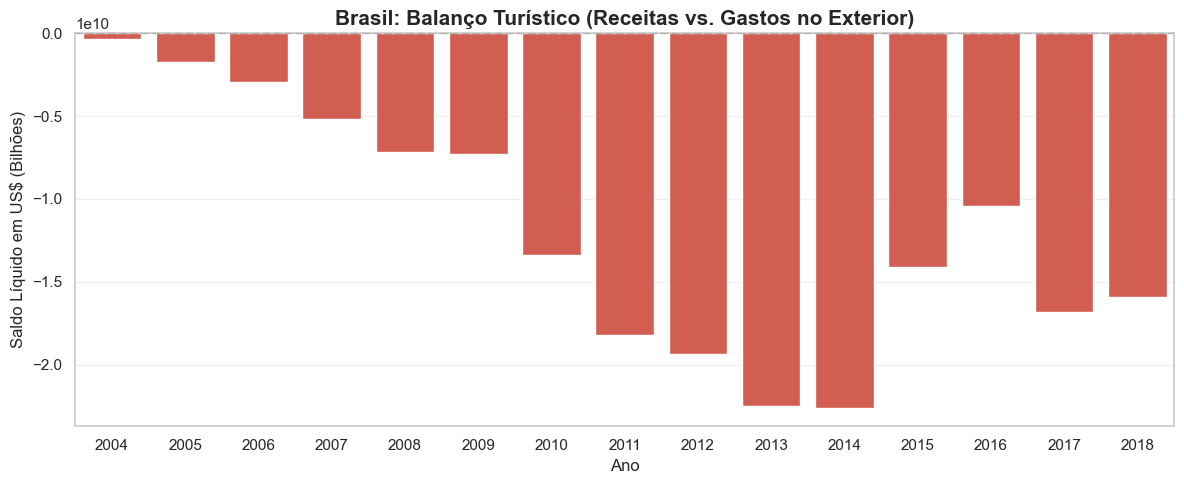

In [505]:
# calculando saldo
df_br_saldo = df[df['País'] == 'Brazil'].sort_values('Ano').copy()
df_br_saldo['Balance'] = df_br_saldo['Receipts'] - df_br_saldo['Expenditures']

# Vermelho para Déficit, Verde para Superávit
df_br_saldo['Color'] = ['#27ae60' if x >= 0 else '#e74c3c' for x in df_br_saldo['Balance']]

plt.figure(figsize=(12, 5))
sns.barplot(data=df_br_saldo, x='Ano', y='Balance', palette=df_br_saldo['Color'].tolist())

# Adicionar linha de referência no zero
plt.axhline(0, color='black', linewidth=1.5, linestyle='--')

plt.title('Brasil: Balanço Turístico (Receitas vs. Gastos no Exterior)', fontsize=15, fontweight='bold')
plt.ylabel('Saldo Líquido em US$ (Bilhões)')
plt.xlabel('Ano')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

O turismo no Brasil cresce em número de visitantes, mas isso não se reflete em dinheiro. Mesmo com mais turistas chegando ao país ao longo dos anos, o Brasil continua gastando muito mais do que ganha com turismo. O problema é que os brasileiros gastam muito no exterior, bem mais do que os estrangeiros gastam aqui. Em 2014, por exemplo, esse desequilíbrio chegou ao pior nível, mesmo com a Copa do Mundo trazendo muitos visitantes.

Depois disso, a situação melhorou um pouco, mas mais porque ficou caro viajar para fora do que por um aumento real de receita no país. No fim, o Brasil continua perdendo dinheiro no turismo: entra menos do que sai.

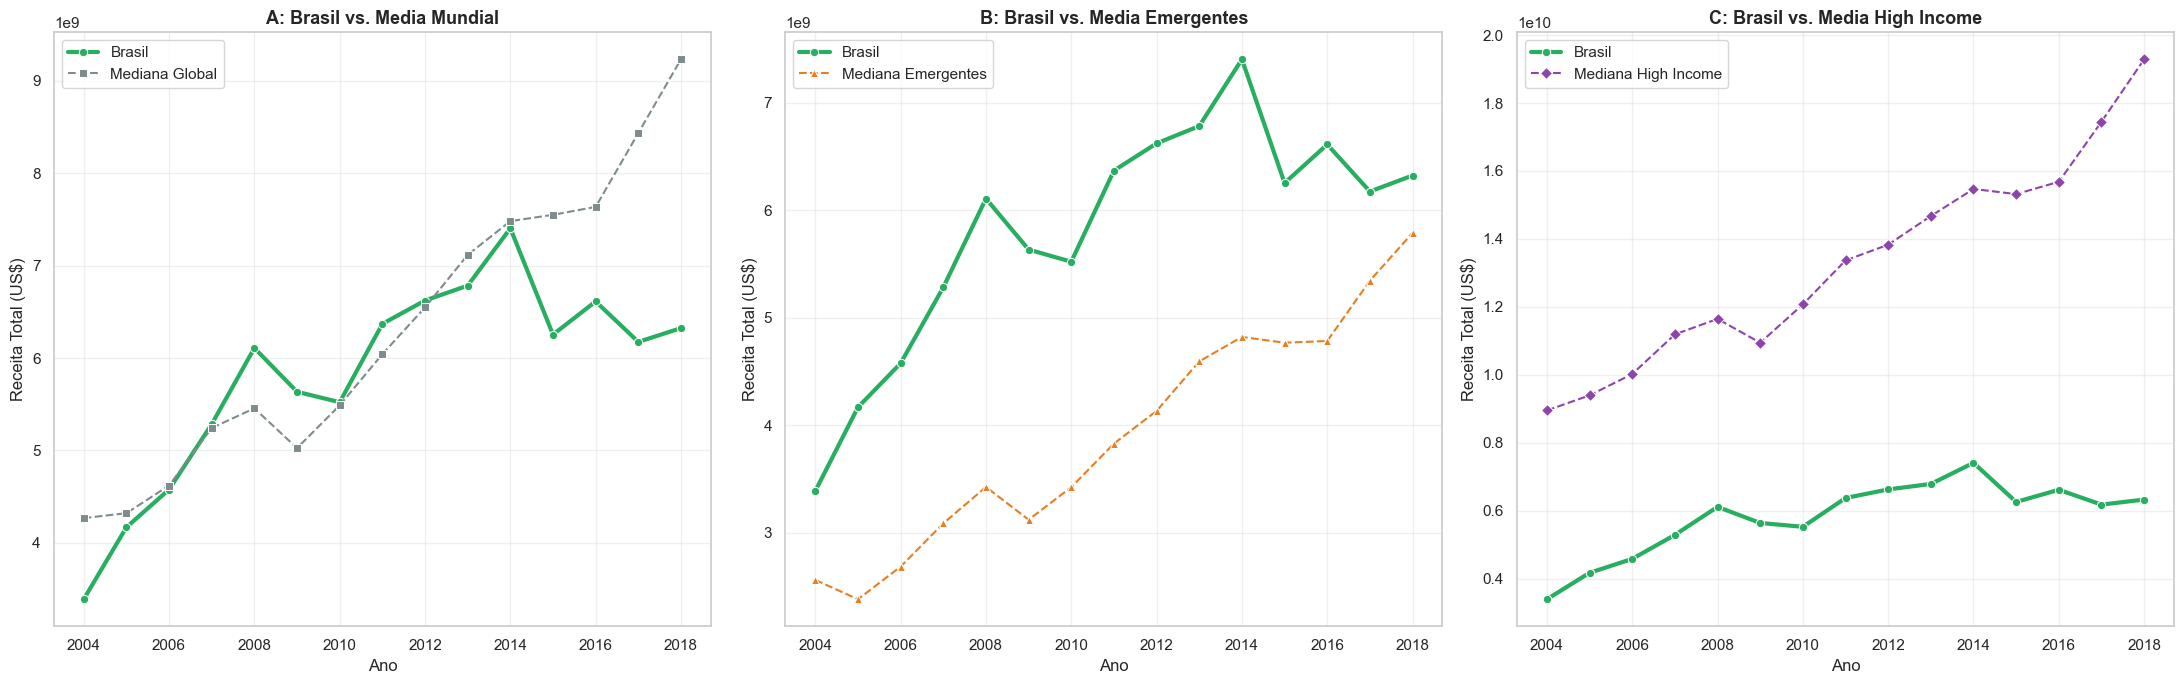

In [508]:
df_brasil = df[df['País'] == 'Brazil'].sort_values('Ano')

# Calculando medianas
mediana_global = df.groupby('Ano')['Receipts'].mean().reset_index()
mediana_emergentes = df[df['IncomeGroup'] == 'Upper middle income'].groupby('Ano')['Receipts'].mean().reset_index()
mediana_high_income = df[df['IncomeGroup'] == 'High income'].groupby('Ano')['Receipts'].mean().reset_index()

# formatando eixo x
def format_usd(x, pos):
    if x >= 1e9: return f'US$ {x*1e-9:.1f}B'
    return f'US$ {x*1e-6:.0f}M'

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 7), sharey=False)

estilo_br = {'marker': 'o', 'linewidth': 3, 'color': '#27ae60', 'label': 'Brasil'}

# Brasil vc media mundial
sns.lineplot(data=df_brasil, x='Ano', y='Receipts', ax=ax1, **estilo_br)
sns.lineplot(data=mediana_global, x='Ano', y='Receipts', ax=ax1, marker='s', color='#7f8c8d', linestyle='--', label='Mediana Global')
ax1.set_title('A: Brasil vs. Media Mundial', fontsize=13, fontweight='bold')

# Brasil vs Upper Middle income
sns.lineplot(data=df_brasil, x='Ano', y='Receipts', ax=ax2, **estilo_br)
sns.lineplot(data=mediana_emergentes, x='Ano', y='Receipts', ax=ax2, marker='^', color='#e67e22', linestyle='--', label='Mediana Emergentes')
ax2.set_title('B: Brasil vs. Media Emergentes', fontsize=13, fontweight='bold')

# brasil vs high income
sns.lineplot(data=df_brasil, x='Ano', y='Receipts', ax=ax3, **estilo_br)
sns.lineplot(data=mediana_high_income, x='Ano', y='Receipts', ax=ax3, marker='D', color='#8e44ad', linestyle='--', label='Mediana High Income')
ax3.set_title('C: Brasil vs. Media High Income', fontsize=13, fontweight='bold')

# Ajustes finais em todos os eixos
for ax in [ax1, ax2, ax3]:
    ax.grid(True, alpha=0.3)
    ax.set_ylabel('Receita Total (US$)')
    ax.set_xlabel('Ano')
    ax.legend()

plt.tight_layout()
plt.show()

O painel mostra que o Brasil teve um bom momento no turismo, especialmente entre 2011 e 2014, quando chegou a ficar acima da média mundial de receitas. Depois disso, o país perdeu ritmo: enquanto o resto do mundo continuou crescendo, o Brasil ficou mais instável e terminou bem atrás.

Entre os países emergentes, o Brasil ainda está na frente, mas essa vantagem está diminuindo. Outros países vêm crescendo de forma mais constante e estão se aproximando. Já quando comparado aos países ricos, a diferença é grande: eles ganham muito mais e crescem mais rápido.

No fim, o Brasil continua sendo forte dentro do seu grupo, mas não conseguiu acompanhar a evolução do turismo global nos últimos anos.


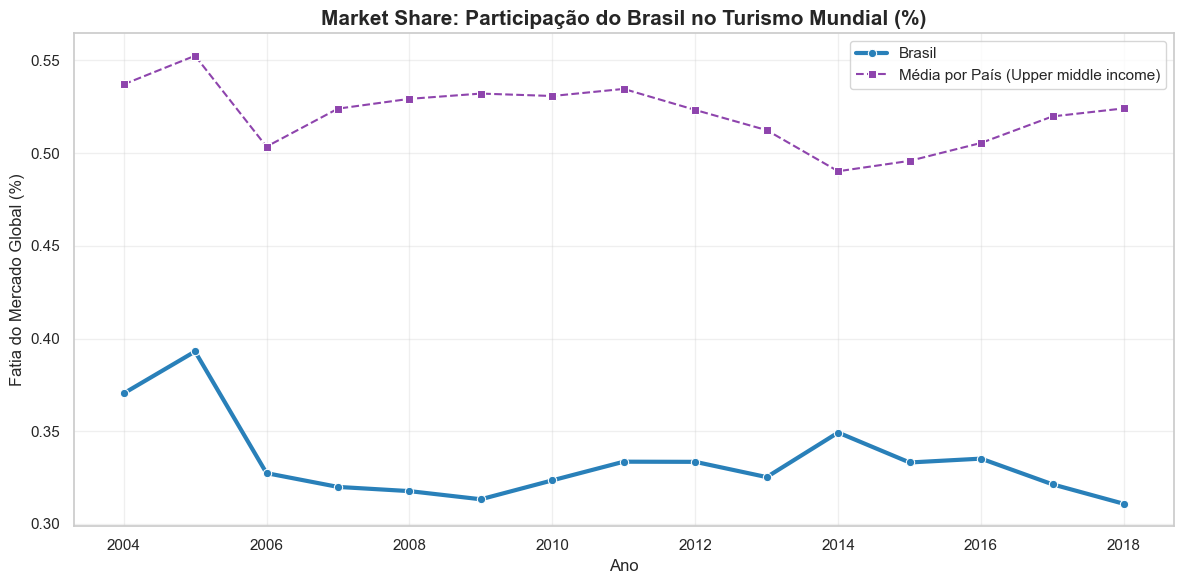

In [ ]:
# calculando total de chegadas por ano
total_global = df.groupby('Ano')['Arrivals'].sum()

# calculando % de participação do brasil em turismo
br_arrivals = df[df['País'] == 'Brazil'].set_index('Ano')['Arrivals']
br_share = (br_arrivals / total_global) * 100

# comparando com media dos paises upper middle income
# Pegamos a soma do grupo, dividimos pelo total global e depois pelo número de países no grupo
hi_data = df[df['IncomeGroup'] == 'Upper middle income']
hi_total_share = (hi_data.groupby('Ano')['Arrivals'].sum() / total_global) * 100
hi_country_count = hi_data.groupby('Ano')['País'].nunique()
hi_share_avg = hi_total_share / hi_country_count

#data frame pronto
df_market = pd.DataFrame({
    'Brasil': br_share,
    'Média Upper middle income': hi_share_avg
}).reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_market, x='Ano', y='Brasil', marker='o', label='Brasil', linewidth=3, color='#2980b9')
sns.lineplot(data=df_market, x='Ano', y='Média Upper middle income', marker='s', label='Média por País (Upper middle income)', color='#8e44ad', linestyle='--')

plt.title('Market Share: Participação do Brasil no Turismo Mundial (%)', fontsize=15, fontweight='bold')
plt.ylabel('Fatia do Mercado Global (%)')
plt.xlabel('Ano')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

Esse gráfico mostra uma realidade meio dura para o Brasil: o país está perdendo espaço no turismo mundial. Mesmo comparado a outros países do mesmo grupo, o Brasil aparece com uma participação menor e não consegue acompanhar o nível médio. Houve apenas um pequeno aumento em 2014 o que poderia ser explicado pela copa do mundo realizada aqui.

Enquanto outros países conseguem manter uma fatia mais estável do mercado, o Brasil vem caindo ao longo do tempo. Em 2018, chegou ao seu pior nível, com uma participação bem baixa. Ou seja, o turismo global está crescendo, mas o Brasil não acompanhou esse crescimento na mesma proporção entre 2004 e 2018.